In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt 
import matplotlib as mpl
import seaborn as sns

from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split, GroupShuffleSplit 

import glob, sys, os, math, gc, sklearn, scipy 

print(f'Tensorflow V{tf.__version__}')
print(f'Keras V{tf.keras.__version__}')
print(f'Python V{sys.version}') 

2026-01-27 21:10:47.049890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769548247.367019      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769548247.468939      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769548248.277391      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769548248.277438      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769548248.277441      24 computation_placer.cc:177] computation placer alr

Tensorflow V2.19.0
Keras V3.10.0
Python V3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
# MatplotLib Global Settings
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 24 

In [3]:
# If True, processing data from scratch
# If False, loads preprocessed data
PREPROCESS_DATA = False  # Set to True if first run with aug
TRAIN_MODEL = True
# True: use 10% of participants as validation set
# False: use all data for training -> gives better LB result
USE_VAL = True  # Enable for early stopping

N_ROWS = 543
N_DIMS = 3
DIM_NAMES = ['x', 'y', 'z']
SEED = 42
NUM_CLASSES = 250
IS_INTERACTIVE = os.environ['KAGGLE_KERNEL_RUN_TYPE'] == 'Interactive'
VERBOSE = 1 if IS_INTERACTIVE else 2

INPUT_SIZE = 64

BATCH_ALL_SIGNS_N = 4
BATCH_SIZE = 64 
N_EPOCHS = 100 # 50
LR_MAX = 1e-3
N_WARMUP_EPOCHS = 0
WD_RATIO = 0.05
MASK_VAL = 4237

In [4]:
# Prints Shape and Dtype For List Of Variables
def print_shape_dtype(l, names):
    for e, n in zip(l, names):
        print(f'{n} shape: {e.shape}, dtype: {e.dtype}') 

In [5]:
# Read Training Data
if IS_INTERACTIVE or not PREPROCESS_DATA:
    train = pd.read_csv('/kaggle/input/asl-signs/train.csv').sample(int(5e3), random_state=SEED)
else:
    train = pd.read_csv('/kaggle/input/asl-signs/train.csv')

N_SAMPLES = len(train)
print(f'N_SAMPLES: {N_SAMPLES}') 

N_SAMPLES: 5000


In [6]:
# Get complete file path to file
def get_file_path(path):
    return f'/kaggle/input/asl-signs/{path}'

train['file_path'] = train['path'].apply(get_file_path) 

# Ordinally Encode Sign

In [7]:
# Add ordinally Encoded Sign (assign number to each sign name)
train['sign_ord'] = train['sign'].astype('category').cat.codes

# Dictionaries to translate sign to ordinal encoded sign
SIGN2ORD = train[['sign', 'sign_ord']].set_index('sign').squeeze().to_dict()
ORD2SIGN = train[['sign_ord', 'sign']].set_index('sign_ord').squeeze().to_dict() 

In [8]:
display(train.sample(n=5)) 
display(train.info()) 

,path,participant_id,sequence_id,sign,file_path,sign_ord
54434,train_landmark_files/28656/3226210910.parquet,28656,3226210910,hen,/kaggle/input/asl-signs/train_landmark_files/2...,114
86907,train_landmark_files/18796/685072923.parquet,18796,685072923,goose,/kaggle/input/asl-signs/train_landmark_files/1...,98
84304,train_landmark_files/34503/581899585.parquet,34503,581899585,bedroom,/kaggle/input/asl-signs/train_landmark_files/3...,18
32440,train_landmark_files/29302/2329369812.parquet,29302,2329369812,that,/kaggle/input/asl-signs/train_landmark_files/2...,215
4939,train_landmark_files/27610/1203885686.parquet,27610,1203885686,shower,/kaggle/input/asl-signs/train_landmark_files/2...,197


<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 56533 to 19516
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            5000 non-null   object
 1   participant_id  5000 non-null   int64 
 2   sequence_id     5000 non-null   int64 
 3   sign            5000 non-null   object
 4   file_path       5000 non-null   object
 5   sign_ord        5000 non-null   int16 
dtypes: int16(1), int64(2), object(3)
memory usage: 244.1+ KB


None

# EDA

In [9]:
N = int(1e3) if (IS_INTERACTIVE or not PREPROCESS_DATA) else int(10e3)
N_UNIQUE_FRAMES = np.zeros(N, dtype=np.uint16)
N_MISSING_FRAMES = np.zeros(N, dtype=np.uint16)
MAX_FRAME = np.zeros(N, dtype=np.uint16)

PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

for idx, file_path in enumerate(tqdm(train['file_path'].sample(N, random_state=SEED))):
    df = pd.read_parquet(file_path)
    N_UNIQUE_FRAMES[idx] = df['frame'].nunique()
    N_MISSING_FRAMES[idx] = (df['frame'].max() - df['frame'].min()) - df['frame'].nunique() + 1
    MAX_FRAME[idx] = df['frame'].max() 

  0%|          | 0/1000 [00:00<?, ?it/s]

,N_UNIQUE_FRAMES
count,1000.000000
mean,37.676000
std,46.188184
min,4.000000
1%,6.000000
5%,6.000000
25%,11.000000
50%,21.000000
75%,43.000000
95%,139.050000


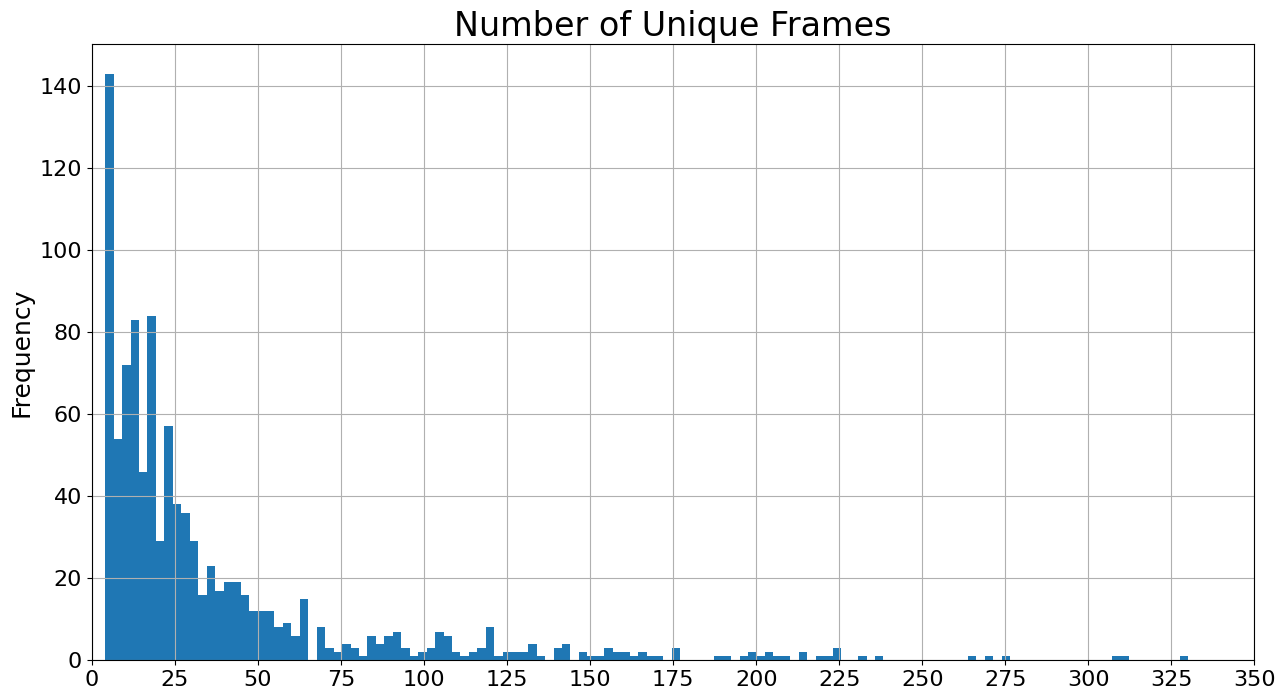

In [10]:
# Number of unique frames in each video
display(pd.Series(N_UNIQUE_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_UNIQUE_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Unique Frames', size=24)
pd.Series(N_UNIQUE_FRAMES).plot(kind='hist', bins=128)
plt.grid()
xlim = math.ceil(plt.xlim()[1])
plt.xlim(0, xlim)
plt.xticks(np.arange(0, xlim+25, 25))
plt.show() 

,N_MISSING_FRAMES
count,1000.000000
mean,0.001000
std,0.031623
min,0.000000
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
95%,0.000000


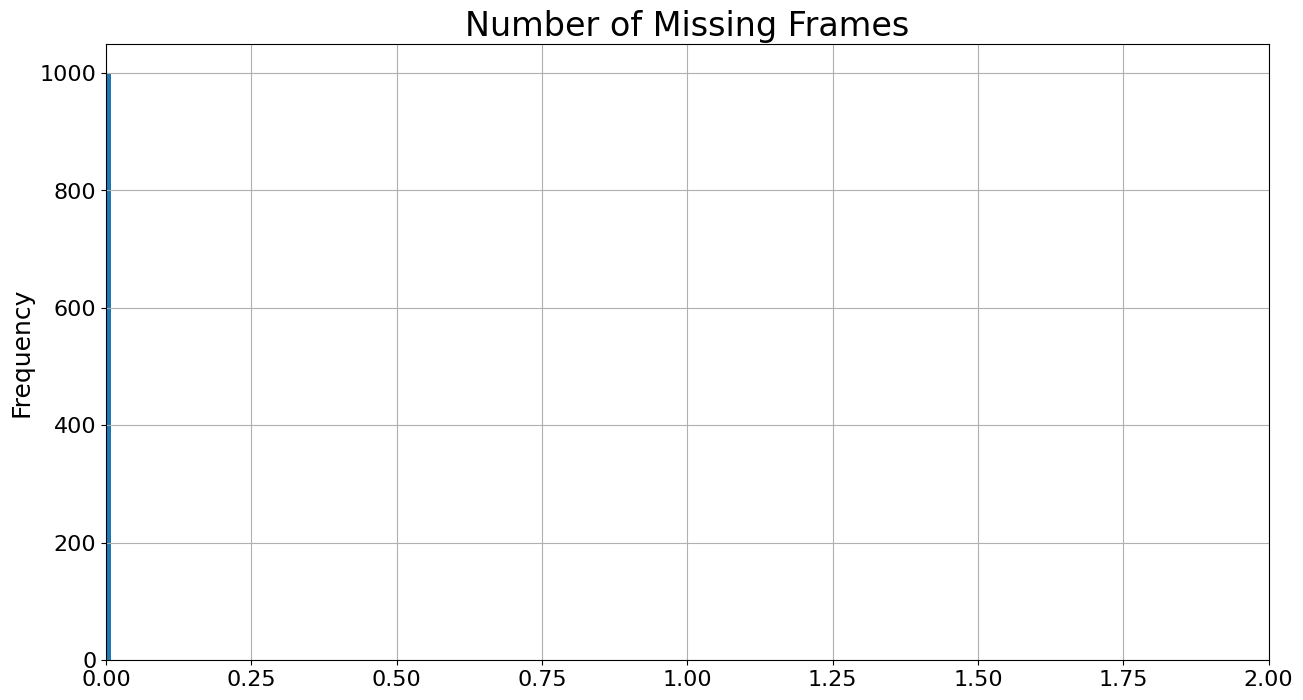

In [11]:
# Number of missing frames, consecutive frames with missing intermediate frame, i.e. 1,2,4,5 but 3 is missing
display(pd.Series(N_MISSING_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_MISSING_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Missing Frames', size=24)
pd.Series(N_MISSING_FRAMES).plot(kind='hist', bins=128)
plt.grid()
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

,MAX_FRAME
count,1000.000000
mean,66.761000
std,59.679222
min,3.000000
1%,12.990000
5%,22.000000
25%,33.000000
50%,42.000000
75%,61.000000
95%,203.050000


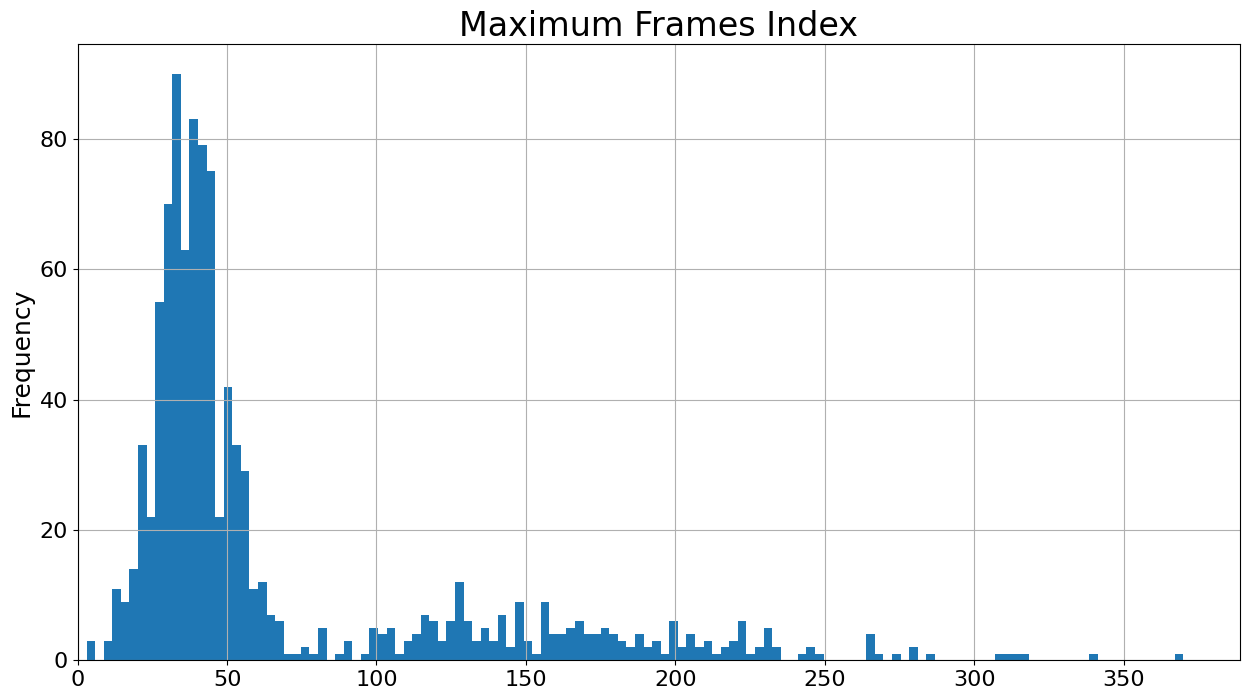

In [12]:
# Maximum frame number
display(pd.Series(MAX_FRAME).describe(percentiles=PERCENTILES).to_frame('MAX_FRAME'))

plt.figure(figsize=(15,8))
plt.title('Maximum Frames Index', size=24)
pd.Series(MAX_FRAME).plot(kind='hist', bins=128)
plt.grid() 
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

# Landmark Indices for Lips, Hands, and Pose

In [13]:
USE_TYPES = ['left_hand', 'pose', 'right_hand']
START_IDX = 468
LIPS_IDXS0 = np.array([
        61, 185, 40, 39, 37, 0, 267, 269, 270, 409,
        291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
        78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
        95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
    ])
# Landmark indices in original data
LEFT_HAND_IDXS0 = np.arange(468,489)
RIGHT_HAND_IDXS0 = np.arange(522,543)
LEFT_POSE_IDXS0 = np.array([502, 504, 506, 508, 510])
RIGHT_POSE_IDXS0 = np.array([503, 505, 507, 509, 511])
LANDMARK_IDXS_LEFT_DOMINANT0 = np.concatenate((LIPS_IDXS0, LEFT_HAND_IDXS0, LEFT_POSE_IDXS0))
LANDMARK_IDXS_RIGHT_DOMINANT0 = np.concatenate((LIPS_IDXS0, RIGHT_HAND_IDXS0, RIGHT_POSE_IDXS0))
HAND_IDXS0 = np.concatenate((LEFT_HAND_IDXS0, RIGHT_HAND_IDXS0), axis=0)
N_COLS = LANDMARK_IDXS_LEFT_DOMINANT0.size
# Landmark indices in processed data
LIPS_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LIPS_IDXS0)).squeeze()
LEFT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_HAND_IDXS0)).squeeze()
RIGHT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, RIGHT_HAND_IDXS0)).squeeze()
HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, HAND_IDXS0)).squeeze()
POSE_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_POSE_IDXS0)).squeeze()

print(f'# HAND_IDXS: {len(HAND_IDXS)}, N_COLS: {N_COLS}')

# HAND_IDXS: 21, N_COLS: 66


In [14]:
LIPS_START = 0
LEFT_HAND_START = LIPS_IDXS.size
RIGHT_HAND_START = LEFT_HAND_START + LEFT_HAND_IDXS.size
POSE_START = RIGHT_HAND_START + RIGHT_HAND_IDXS.size

print(f'LIPS_START: {LIPS_START}, LEFT_HAND_START: {LEFT_HAND_START}, RIGHT_HAND_START: {RIGHT_HAND_START}, POSE_START: {POSE_START}') 

LIPS_START: 0, LEFT_HAND_START: 40, RIGHT_HAND_START: 61, POSE_START: 61


# Process Data Tensorflow

In [15]:
ROWS_PER_FRAME = 543  # number of landmarks per frame

def load_relevant_data_subset(pq_path):
    data_columns = ['x', 'y', 'z']
    data = pd.read_parquet(pq_path, columns=data_columns)
    n_frames = int(len(data) / ROWS_PER_FRAME)
    data = data.values.reshape(n_frames, ROWS_PER_FRAME, len(data_columns))
    return data.astype(np.float32) 

In [16]:
class PreprocessLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(PreprocessLayer, self).__init__()
        normalisation_correction = tf.constant([
                    # Add 0.50 to left hand (original right hand) and substract 0.50 of right hand (original left hand)
                    [0] * len(LIPS_IDXS) + [0.50] * len(LEFT_HAND_IDXS) + [0.50] * len(POSE_IDXS),
                    # Y coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                    # Z coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                ],
                dtype=tf.float32,
            )
        self.normalisation_correction = tf.transpose(normalisation_correction, [1,0])
        
    def pad_edge(self, t, repeats, side):
        if side == 'LEFT':
            return tf.concat((tf.repeat(t[:1], repeats=repeats, axis=0), t), axis=0)
        elif side == 'RIGHT':
            return tf.concat((t, tf.repeat(t[-1:], repeats=repeats, axis=0)), axis=0)
    
    @tf.function(
        input_signature=(tf.TensorSpec(shape=[None,N_ROWS,N_DIMS], dtype=tf.float32),),
    )
    def call(self, data0):
        # Number of Frames in Video
        N_FRAMES0 = tf.shape(data0)[0]
        
        # Find dominant hand by comparing summed absolute coordinates
        left_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1))
        right_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1))
        left_dominant = left_hand_sum >= right_hand_sum
        
        # Count non-NaN Hand values in each frame for the dominant hand
        if left_dominant:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        else:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        
        # Find frames indices with coordinates of the dominant hand
        non_empty_frames_idxs = tf.where(frames_hands_non_nan_sum > 0)
        non_empty_frames_idxs = tf.squeeze(non_empty_frames_idxs, axis=1)
        # Filter frames
        data = tf.gather(data0, non_empty_frames_idxs, axis=0)
        
        # Cast Indices in float32 to be compatible with Tensorflow Lite
        non_empty_frames_idxs = tf.cast(non_empty_frames_idxs, tf.float32)
        # Normalize to start with 0
        non_empty_frames_idxs -= tf.reduce_min(non_empty_frames_idxs)
        
        # Number of Frames in Filtered Video
        N_FRAMES = tf.shape(data)[0]
        
        # Gather Relevant Landmark Columns
        if left_dominant:
            data = tf.gather(data, LANDMARK_IDXS_LEFT_DOMINANT0, axis=1)
        else:
            data = tf.gather(data, LANDMARK_IDXS_RIGHT_DOMINANT0, axis=1)
            data = (
                    self.normalisation_correction + (
                        (data - self.normalisation_correction) * tf.where(self.normalisation_correction != 0, -1.0, 1.0))
                )
        
        # Video fits in INPUT_SIZE
        if N_FRAMES < INPUT_SIZE:
            # Pad With -1 to indicate padding
            non_empty_frames_idxs = tf.pad(non_empty_frames_idxs, [[0, INPUT_SIZE-N_FRAMES]], constant_values=-1)
            # Pad Data With Zeros
            data = tf.pad(data, [[0, INPUT_SIZE-N_FRAMES], [0,0], [0,0]], constant_values=0)
            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
            return data, non_empty_frames_idxs
        # Video needs to be downsampled to INPUT_SIZE
        else:
            # Repeat
            if N_FRAMES < INPUT_SIZE**2:
                repeats = tf.math.floordiv(INPUT_SIZE * INPUT_SIZE, N_FRAMES0)
                data = tf.repeat(data, repeats=repeats, axis=0)
                non_empty_frames_idxs = tf.repeat(non_empty_frames_idxs, repeats=repeats, axis=0)

            # Pad To Multiple Of Input Size
            pool_size = tf.math.floordiv(len(data), INPUT_SIZE)
            if tf.math.mod(len(data), INPUT_SIZE) > 0:
                pool_size += 1

            if pool_size == 1:
                pad_size = (pool_size * INPUT_SIZE) - len(data)
            else:
                pad_size = (pool_size * INPUT_SIZE) % len(data)

            # Pad Start/End with Start/End value
            pad_left = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            pad_right = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            if tf.math.mod(pad_size, 2) > 0:
                pad_right += 1

            # Pad By Concatenating Left/Right Edge Values
            data = self.pad_edge(data, pad_left, 'LEFT')
            data = self.pad_edge(data, pad_right, 'RIGHT')

            # Pad Non Empty Frame Indices
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_left, 'LEFT')
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_right, 'RIGHT')

            # Reshape to Mean Pool
            data = tf.reshape(data, [INPUT_SIZE, -1, N_COLS, N_DIMS])
            non_empty_frames_idxs = tf.reshape(non_empty_frames_idxs, [INPUT_SIZE, -1])

            # Mean Pool
            data = tf.experimental.numpy.nanmean(data, axis=1)
            non_empty_frames_idxs = tf.experimental.numpy.nanmean(non_empty_frames_idxs, axis=1)

            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
            
            return data, non_empty_frames_idxs
    
preprocess_layer = PreprocessLayer() 

I0000 00:00:1769548295.073930      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [17]:
"""
    face: 0:468
    left_hand: 468:489
    pose: 489:522
    right_hand: 522:544
        
"""
def get_data(file_path):
    # Load Raw Data
    data = load_relevant_data_subset(file_path)
    # Process Data Using Tensorflow
    data = preprocess_layer(data)
    
    return data 

In [18]:
# Get the full dataset
def preprocess_data():
    # Create arrays to save data
    X = np.zeros([N_SAMPLES, INPUT_SIZE, N_COLS, N_DIMS], dtype=np.float32)
    y = np.zeros([N_SAMPLES], dtype=np.int32)
    NON_EMPTY_FRAME_IDXS = np.full([N_SAMPLES, INPUT_SIZE], -1, dtype=np.float32)

    # Fill X/y
    for row_idx, (file_path, sign_ord) in enumerate(tqdm(train[['file_path', 'sign_ord']].values)):
        # Log message every 5000 samples
        if row_idx % 5000 == 0:
            print(f'Generated {row_idx}/{N_SAMPLES}')

        data, non_empty_frame_idxs = get_data(file_path)
        X[row_idx] = data
        y[row_idx] = sign_ord
        NON_EMPTY_FRAME_IDXS[row_idx] = non_empty_frame_idxs
        # Sanity check, data should not contain NaN values
        if np.isnan(data).sum() > 0:
            print(row_idx)
            return data

    # Save X/y
    np.save('X.npy', X)
    np.save('y.npy', y)
    np.save('NON_EMPTY_FRAME_IDXS.npy', NON_EMPTY_FRAME_IDXS)
    
    # Save Validation
    splitter = GroupShuffleSplit(test_size=0.10, n_splits=2, random_state=SEED)
    PARTICIPANT_IDS = train['participant_id'].values
    train_idxs, val_idxs = next(splitter.split(X, y, groups=PARTICIPANT_IDS))

    # Save Train
    X_train = X[train_idxs]
    NON_EMPTY_FRAME_IDXS_TRAIN = NON_EMPTY_FRAME_IDXS[train_idxs]
    y_train = y[train_idxs]
    np.save('X_train.npy', X_train)
    np.save('y_train.npy', y_train)
    np.save('NON_EMPTY_FRAME_IDXS_TRAIN.npy', NON_EMPTY_FRAME_IDXS_TRAIN)
    # Save Validation
    X_val = X[val_idxs]
    NON_EMPTY_FRAME_IDXS_VAL = NON_EMPTY_FRAME_IDXS[val_idxs]
    y_val = y[val_idxs]
    np.save('X_val.npy', X_val)
    np.save('y_val.npy', y_val)
    np.save('NON_EMPTY_FRAME_IDXS_VAL.npy', NON_EMPTY_FRAME_IDXS_VAL)
    # Split Statistics
    print(f'Patient ID Intersection Train/Val: {set(PARTICIPANT_IDS[train_idxs]).intersection(PARTICIPANT_IDS[val_idxs])}')
    print(f'X_train shape: {X_train.shape}, X_val shape: {X_val.shape}')
    print(f'y_train shape: {y_train.shape}, y_val shape: {y_val.shape}') 

In [19]:
# Preprocess All Data From Scratch
if PREPROCESS_DATA:
    preprocess_data()
    ROOT_DIR = '.'
else:
    ROOT_DIR = '/kaggle/input/gislr-dataset-public'
    
# Load Data
if USE_VAL:
    # Load Train
    X_train = np.load(f'{ROOT_DIR}/X_train.npy')
    y_train = np.load(f'{ROOT_DIR}/y_train.npy')
    NON_EMPTY_FRAME_IDXS_TRAIN = np.load(f'{ROOT_DIR}/NON_EMPTY_FRAME_IDXS_TRAIN.npy')
    # Load Val
    X_val = np.load(f'{ROOT_DIR}/X_val.npy') 
    y_val = np.load(f'{ROOT_DIR}/y_val.npy')
    NON_EMPTY_FRAME_IDXS_VAL = np.load(f'{ROOT_DIR}/NON_EMPTY_FRAME_IDXS_VAL.npy')
    # Define validation Data
    y_val_oh = tf.one_hot(y_val, NUM_CLASSES)
    validation_data = ({ 'frames': X_val, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL }, y_val_oh)
else:
    X_train = np.load(f'{ROOT_DIR}/X.npy')
    y_train = np.load(f'{ROOT_DIR}/y.npy')
    NON_EMPTY_FRAME_IDXS_TRAIN = np.load(f'{ROOT_DIR}/NON_EMPTY_FRAME_IDXS.npy')
    validation_data = None

# Train 
print_shape_dtype([X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN], ['X_train', 'y_train', 'NON_EMPTY_FRAME_IDXS_TRAIN'])
# Val
if USE_VAL:
    print_shape_dtype([X_val, y_val, NON_EMPTY_FRAME_IDXS_VAL], ['X_val', 'y_val', 'NON_EMPTY_FRAME_IDXS_VAL'])
# Sanity Check
print(f'# NaN Values X_train: {np.isnan(X_train).sum()}') 

X_train shape: (80229, 64, 66, 3), dtype: float32
y_train shape: (80229,), dtype: int32
NON_EMPTY_FRAME_IDXS_TRAIN shape: (80229, 64), dtype: float32
X_val shape: (14248, 64, 66, 3), dtype: float32
y_val shape: (14248,), dtype: int32
NON_EMPTY_FRAME_IDXS_VAL shape: (14248, 64), dtype: float32
# NaN Values X_train: 0


In [20]:
# Class Count
display(pd.Series(y_train).value_counts().to_frame('Class Count').iloc[[0,1,2,3,4, -5,-4,-3,-2,-1]]) 

,Class Count
135,358
136,352
60,351
194,351
67,348
170,277
249,267
56,266
21,263
231,255


# Number of Frames

  0%|          | 0/64 [00:00<?, ?it/s]

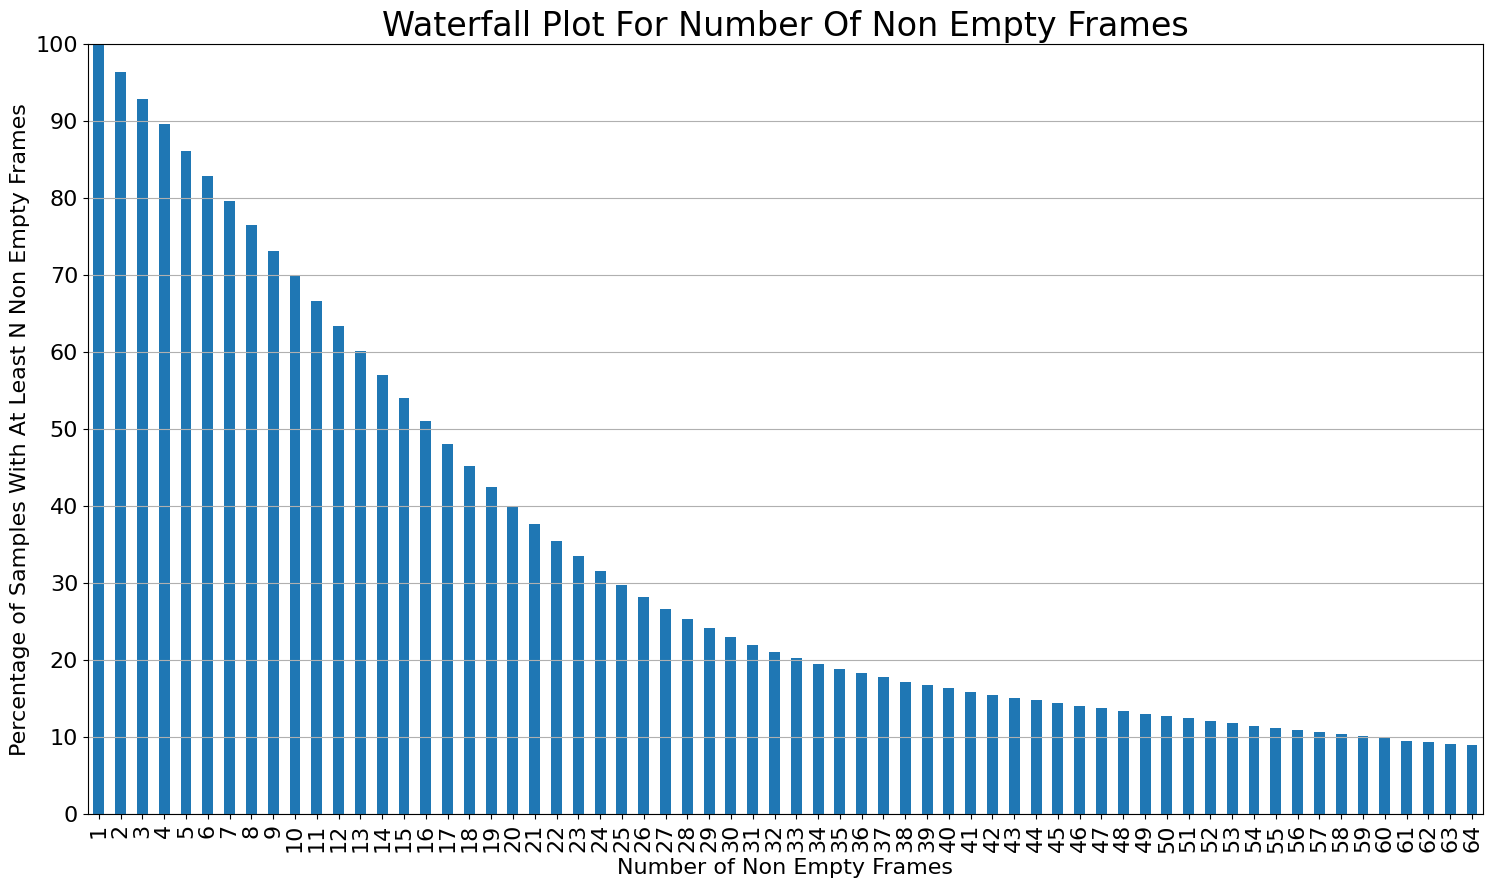

In [21]:
# Vast majority of samples fits has less than 32 non empty frames
N_EMPTY_FRAMES = (NON_EMPTY_FRAME_IDXS_TRAIN != -1).sum(axis=1) 
N_EMPTY_FRAMES_WATERFALL = []
for n in tqdm(range(1,INPUT_SIZE+1)):
    N_EMPTY_FRAMES_WATERFALL.append(sum(N_EMPTY_FRAMES >= n) / len(NON_EMPTY_FRAME_IDXS_TRAIN) * 100)

plt.figure(figsize=(18,10))
plt.title('Waterfall Plot For Number Of Non Empty Frames')
pd.Series(N_EMPTY_FRAMES_WATERFALL).plot(kind='bar')
plt.grid(axis='y')
plt.xticks(np.arange(INPUT_SIZE), np.arange(1, INPUT_SIZE+1))
plt.xlabel('Number of Non Empty Frames', size=16)
plt.yticks(np.arange(0, 100+10, 10))
plt.ylim(0, 100)
plt.ylabel('Percentage of Samples With At Least N Non Empty Frames', size=16)
plt.show() 

# Percentage of Frames Filled

In [22]:
# Percentage of frames filled, this is the maximum fill percentage of each landmark
P_DATA_FILLED = (NON_EMPTY_FRAME_IDXS_TRAIN != -1).sum() / NON_EMPTY_FRAME_IDXS_TRAIN.size * 100
print(f'P_DATA_FILLED: {P_DATA_FILLED:.2f}%') 

P_DATA_FILLED: 33.59%


# Feature Statistics - Lips

In [23]:
# Percentage of Lips Measurements
P_LEFT_LIPS_MEASUREMENTS = (X_train[:,:,LIPS_IDXS] != 0).sum() / X_train[:,:,LIPS_IDXS].size / P_DATA_FILLED * 1e4
print(f'P_LEFT_LIPS_MEASUREMENTS: {P_LEFT_LIPS_MEASUREMENTS:.2f}%') 

P_LEFT_LIPS_MEASUREMENTS: 99.34%


  0%|          | 0/40 [00:00<?, ?it/s]

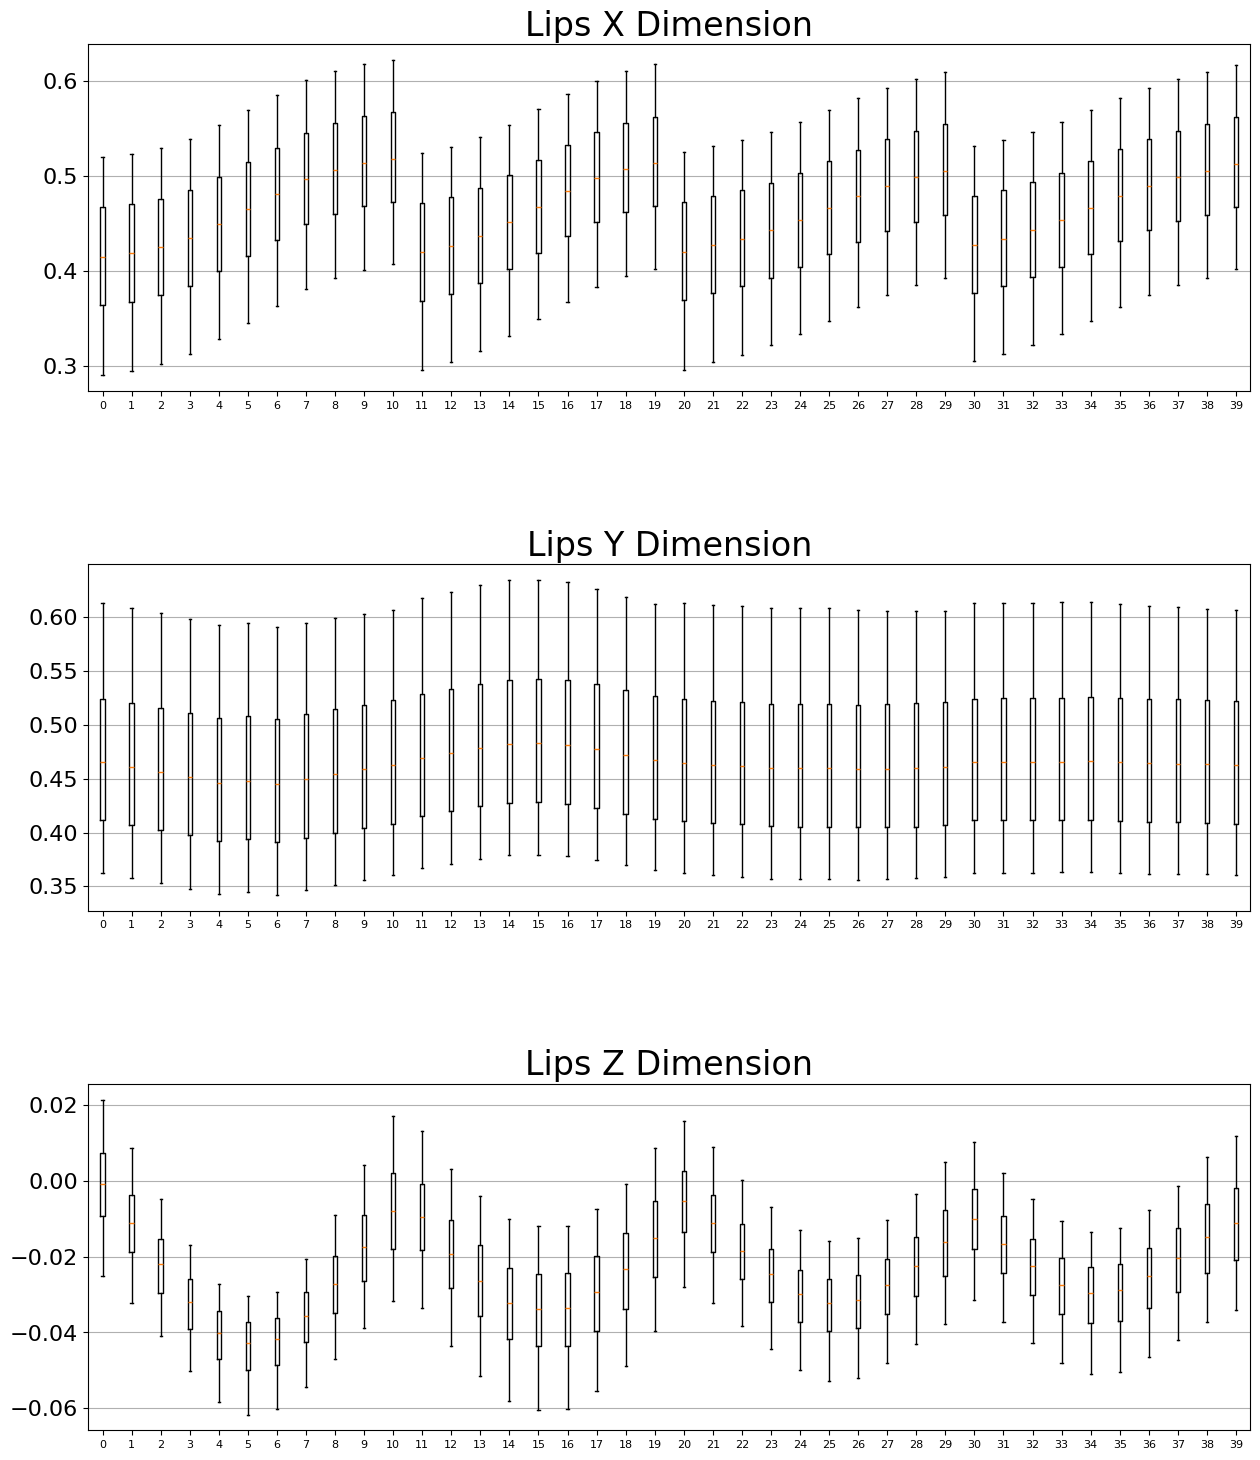

In [24]:
def get_lips_mean_std():
    # LIPS
    LIPS_MEAN_X = np.zeros([LIPS_IDXS.size], dtype=np.float32)
    LIPS_MEAN_Y = np.zeros([LIPS_IDXS.size], dtype=np.float32)
    LIPS_STD_X = np.zeros([LIPS_IDXS.size], dtype=np.float32)
    LIPS_STD_Y = np.zeros([LIPS_IDXS.size], dtype=np.float32)

    fig, axes = plt.subplots(3, 1, figsize=(15, N_DIMS*6))

    for col, ll in enumerate(tqdm( np.transpose(X_train[:,:,LIPS_IDXS], [2,3,0,1]).reshape([LIPS_IDXS.size, N_DIMS, -1]) )):
        for dim, l in enumerate(ll):
            v = l[np.nonzero(l)]
            if dim == 0: # X
                LIPS_MEAN_X[col] = v.mean()
                LIPS_STD_X[col] = v.std()
            if dim == 1: # Y
                LIPS_MEAN_Y[col] = v.mean()
                LIPS_STD_Y[col] = v.std()

            axes[dim].boxplot(v, notch=False, showfliers=False, positions=[col], whis=[5,95])

    for ax, dim_name in zip(axes, DIM_NAMES):
        ax.set_title(f'Lips {dim_name.upper()} Dimension', size=24)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(axis='y')

    plt.subplots_adjust(hspace=0.50)
    plt.show()

    LIPS_MEAN = np.array([LIPS_MEAN_X, LIPS_MEAN_Y]).T
    LIPS_STD = np.array([LIPS_STD_X, LIPS_STD_Y]).T
    
    return LIPS_MEAN, LIPS_STD

LIPS_MEAN, LIPS_STD = get_lips_mean_std() 

# Feature Statistics - Hands

In [25]:
# Verify Normalised to Left Hand Dominant
P_LEFT_HAND_MEASUREMENTS = (X_train[:,:,LEFT_HAND_IDXS] != 0).sum() / X_train[:,:,LEFT_HAND_IDXS].size / P_DATA_FILLED * 1e4
# P_RIGHT_HAND_MEASUREMENTS = (X_train[:,:,RIGHT_HAND_IDXS] != 0).sum() / X_train[:,:,RIGHT_HAND_IDXS].size / P_DATA_FILLED * 1e4
print(f'P_LEFT_HAND_MEASUREMENTS: {P_LEFT_HAND_MEASUREMENTS:.2f}%') 

P_LEFT_HAND_MEASUREMENTS: 100.00%


  0%|          | 0/21 [00:00<?, ?it/s]

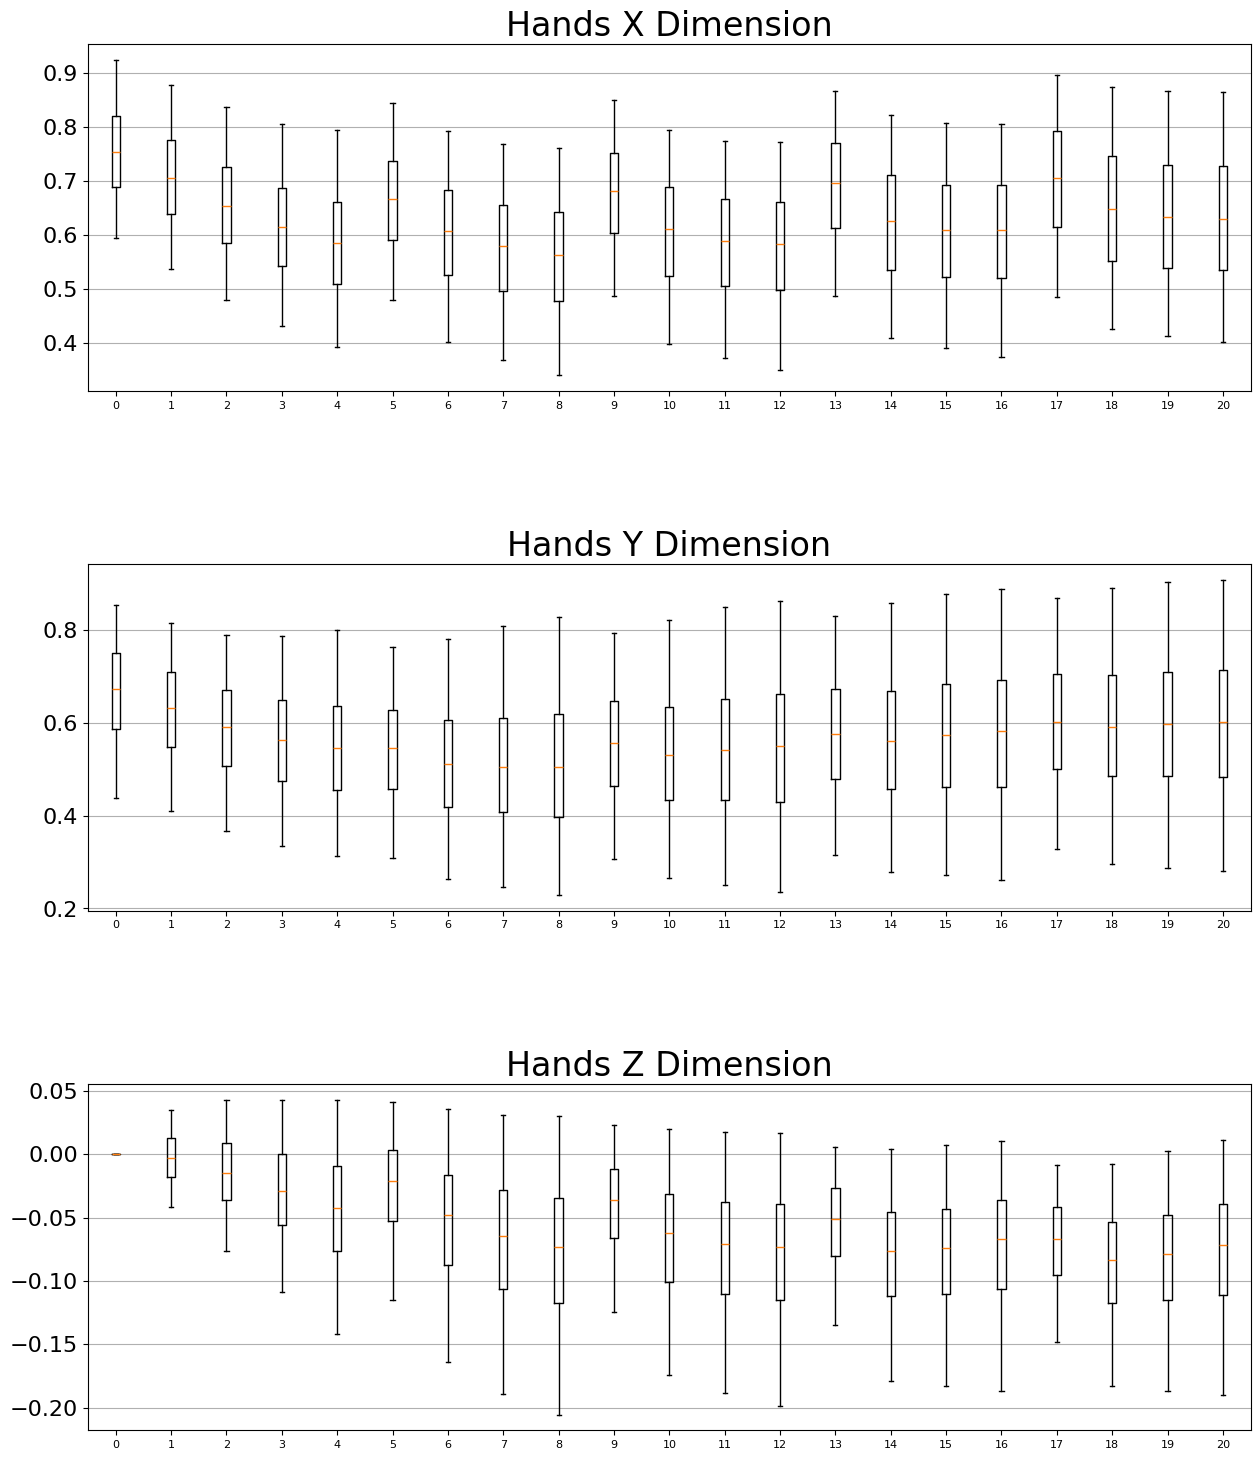

In [26]:
def get_left_right_hand_mean_std():
    # LEFT HAND
    LEFT_HANDS_MEAN_X = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)
    LEFT_HANDS_MEAN_Y = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)
    LEFT_HANDS_STD_X = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)
    LEFT_HANDS_STD_Y = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)

    fig, axes = plt.subplots(3, 1, figsize=(15, N_DIMS*6))

    for col, ll in enumerate(tqdm( np.transpose(X_train[:,:,LEFT_HAND_IDXS], [2,3,0,1]).reshape([LEFT_HAND_IDXS.size, N_DIMS, -1]) )):
        for dim, l in enumerate(ll):
            v = l[np.nonzero(l)]
            if dim == 0: # X
                LEFT_HANDS_MEAN_X[col] = v.mean()
                LEFT_HANDS_STD_X[col] = v.std()
            if dim == 1: # Y
                LEFT_HANDS_MEAN_Y[col] = v.mean()
                LEFT_HANDS_STD_Y[col] = v.std()
            # Plot
            axes[dim].boxplot(v, notch=False, showfliers=False, positions=[col], whis=[5,95])

    for ax, dim_name in zip(axes, DIM_NAMES):
        ax.set_title(f'Hands {dim_name.upper()} Dimension', size=24)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(axis='y')

    plt.subplots_adjust(hspace=0.50)
    plt.show()

    LEFT_HANDS_MEAN = np.array([LEFT_HANDS_MEAN_X, LEFT_HANDS_MEAN_Y]).T
    LEFT_HANDS_STD = np.array([LEFT_HANDS_STD_X, LEFT_HANDS_STD_Y]).T
    
    return LEFT_HANDS_MEAN, LEFT_HANDS_STD

LEFT_HANDS_MEAN, LEFT_HANDS_STD = get_left_right_hand_mean_std() 

# Feature Statistics - Pose

In [27]:
# Percentage of Lips Measurements
P_POSE_MEASUREMENTS = (X_train[:,:,POSE_IDXS] != 0).sum() / X_train[:,:,POSE_IDXS].size / P_DATA_FILLED * 1e4
print(f'P_POSE_MEASUREMENTS: {P_POSE_MEASUREMENTS:.2f}%') 

P_POSE_MEASUREMENTS: 100.00%


  0%|          | 0/5 [00:00<?, ?it/s]

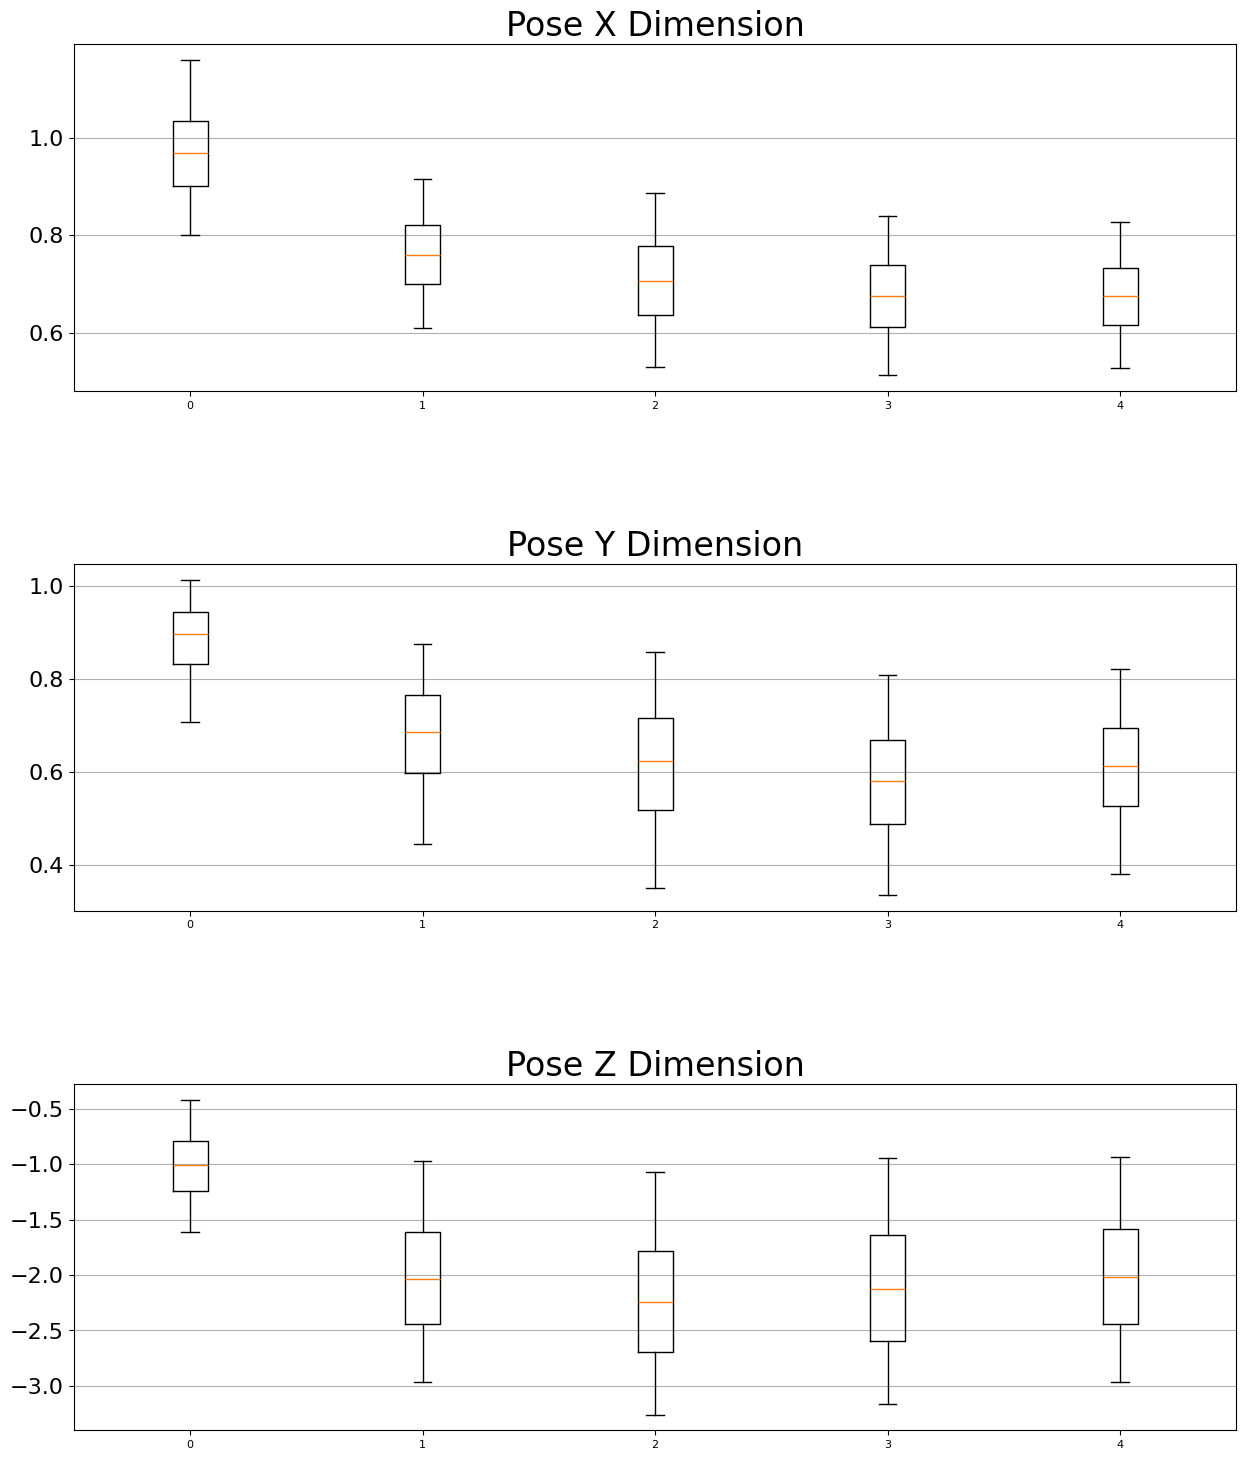

In [28]:
def get_pose_mean_std():
    # POSE
    POSE_MEAN_X = np.zeros([POSE_IDXS.size], dtype=np.float32)
    POSE_MEAN_Y = np.zeros([POSE_IDXS.size], dtype=np.float32)
    POSE_STD_X = np.zeros([POSE_IDXS.size], dtype=np.float32)
    POSE_STD_Y = np.zeros([POSE_IDXS.size], dtype=np.float32)

    fig, axes = plt.subplots(3, 1, figsize=(15, N_DIMS*6))

    for col, ll in enumerate(tqdm( np.transpose(X_train[:,:,POSE_IDXS], [2,3,0,1]).reshape([POSE_IDXS.size, N_DIMS, -1]) )):
        for dim, l in enumerate(ll):
            v = l[np.nonzero(l)]
            if dim == 0: # X
                POSE_MEAN_X[col] = v.mean()
                POSE_STD_X[col] = v.std()
            if dim == 1: # Y
                POSE_MEAN_Y[col] = v.mean()
                POSE_STD_Y[col] = v.std()

            axes[dim].boxplot(v, notch=False, showfliers=False, positions=[col], whis=[5,95])

    for ax, dim_name in zip(axes, DIM_NAMES):
        ax.set_title(f'Pose {dim_name.upper()} Dimension', size=24)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(axis='y')

    plt.subplots_adjust(hspace=0.50)
    plt.show()

    POSE_MEAN = np.array([POSE_MEAN_X, POSE_MEAN_Y]).T
    POSE_STD = np.array([POSE_STD_X, POSE_STD_Y]).T
    
    return POSE_MEAN, POSE_STD

POSE_MEAN, POSE_STD = get_pose_mean_std() 

# Samples

In [29]:
# Custom sampler to get a batch containing N times all signs
def get_train_batch_all_signs(X, y, NON_EMPTY_FRAME_IDXS, n=BATCH_ALL_SIGNS_N, mixup_alpha=0.4):
    # Dictionary mapping ordinally encoded sign to corresponding sample indices
    CLASS2IDXS = {}
    for i in range(NUM_CLASSES):
        CLASS2IDXS[i] = np.argwhere(y == i).squeeze().astype(np.int32)
            
    while True:
        # Arrays to store batch
        X_batch = np.zeros([NUM_CLASSES*n, INPUT_SIZE, N_COLS, N_DIMS], dtype=np.float32)
        # One-hot labels
        y_batch = np.zeros([NUM_CLASSES*n, NUM_CLASSES], dtype=np.float32)
        non_empty_frame_idxs_batch = np.zeros([NUM_CLASSES*n, INPUT_SIZE], dtype=np.float32)

        # Fill batch arrays
        for i in range(NUM_CLASSES):
            idxs = np.random.choice(CLASS2IDXS[i], n)
            X_batch[i*n:(i+1)*n] = X[idxs]
            non_empty_frame_idxs_batch[i*n:(i+1)*n] = NON_EMPTY_FRAME_IDXS[idxs]
            y_batch[i*n:(i+1)*n, i] = 1.0
        
        # Add augmentation and noise (on-the-fly)
        for b in range(X_batch.shape[0]):
            # Geometric Augmentation
            def augment_points(points):
                if len(points) == 0:
                    return points
                # Centroid for all points in sample
                centroid = np.mean(points, axis=0)
                points_centered = points - centroid
                # Rotate
                angle = np.random.uniform(-15, 15) * np.pi / 180
                rot_matrix = np.array([[np.cos(angle), -np.sin(angle)], 
                                       [np.sin(angle), np.cos(angle)]])
                points_rot = points_centered @ rot_matrix.T
                # Scale
                scale = np.random.uniform(0.85, 1.15)
                points_scaled = points_rot * scale
                # Translate
                trans = np.random.uniform(-0.1, 0.1, 2)
                points_trans = points_scaled + trans
                # Back to original
                points_aug = points_trans + centroid
                # Noise
                points_aug += np.random.normal(0, 0.02, points_aug.shape)
                return points_aug
            
            # Process each landmark group
            for start_idx, num_points, group_idxs in [
                (LIPS_START, LIPS_IDXS.size, LIPS_IDXS),
                (LEFT_HAND_START, LEFT_HAND_IDXS.size, LEFT_HAND_IDXS),
                (POSE_START, POSE_IDXS.size, POSE_IDXS)
            ]:
                group_xy = X_batch[b, :, group_idxs, :2]  # (64, num_points, 2)
                mask = np.any(group_xy != 0, axis=-1)  # (64, num_points)
                if np.any(mask):
                    frame_idxs, point_idxs = np.where(mask)
                    non_zero_coords = group_xy[frame_idxs, point_idxs, :]  # (N_nonzero, 2)
                    augmented_coords = augment_points(non_zero_coords)
                    group_xy[frame_idxs, point_idxs, :] = augmented_coords
                X_batch[b, :, group_idxs, :2] = group_xy
            
            # Feature Masking (Random landmark dropout)
            if np.random.rand() < 0.3:
                # Drop random 10% to 30% of landmarks
                drop_mask = np.random.rand(N_COLS) < np.random.uniform(0.1, 0.3)
                X_batch[b, :, drop_mask, :] = 0

            # Time Masking (Random frame dropout)
            if np.random.rand() < 0.5:
                # Drop contiguous frames
                len_mask = np.random.randint(2, 12)
                start_mask = np.random.randint(0, INPUT_SIZE - len_mask)
                X_batch[b, start_mask:start_mask+len_mask, :, :] = 0
                non_empty_frame_idxs_batch[b, start_mask:start_mask+len_mask] = -1

        # MixUp
        if mixup_alpha > 0 and np.random.rand() < 0.7:  # 70% chance to mixup
            lam = np.random.beta(mixup_alpha, mixup_alpha)
            perm_indices = np.random.permutation(X_batch.shape[0])
            
            X_batch = lam * X_batch + (1 - lam) * X_batch[perm_indices]
            y_batch = lam * y_batch + (1 - lam) * y_batch[perm_indices]
            
            # For non_empty_frame_idxs, take the dominant one
            if lam < 0.5:
                non_empty_frame_idxs_batch = non_empty_frame_idxs_batch[perm_indices]
        
        yield { 'frames': X_batch, 'non_empty_frame_idxs': non_empty_frame_idxs_batch }, y_batch


In [30]:
dummy_dataset = get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN)
X_batch, y_batch = next(dummy_dataset)

for k, v in X_batch.items():
    print(f'{k} shape: {v.shape}, dtype: {v.dtype}')

# Batch shape/dtype
print(f'y_batch shape: {y_batch.shape}, dtype: {y_batch.dtype}')
# Verify each batch contains each sign exactly N times
display(pd.Series(np.argmax(y_batch, axis=1)).value_counts().to_frame('Counts')) 

frames shape: (1000, 64, 66, 3), dtype: float32
non_empty_frame_idxs shape: (1000, 64), dtype: float32
y_batch shape: (1000, 250), dtype: float32


,Counts
0,4
1,4
2,4
3,4
4,4
...,...
245,4
246,4
247,4
248,4


# Model Config

In [31]:
# Epsilon value for layer normalisation
LAYER_NORM_EPS = 1e-6

# Dense layer units for landmarks
LIPS_UNITS = 192 # 384 or 128
HANDS_UNITS = 192 # 384
POSE_UNITS = 192 # 384
# final embedding and transformer embedding size
UNITS = 320 # 512 or 320

# Transformer
NUM_BLOCKS = 2
MLP_RATIO = 2

# Dropout
EMBEDDING_DROPOUT = 0.05 #0.00
MLP_DROPOUT_RATIO = 0.25 #0.30
CLASSIFIER_DROPOUT_RATIO = 0.30 #0.10
#LANDMARK_DROPOUT_RATIO = 0.45

# Initiailizers
INIT_HE_UNIFORM = tf.keras.initializers.he_uniform
INIT_GLOROT_UNIFORM = tf.keras.initializers.glorot_uniform
INIT_ZEROS = tf.keras.initializers.constant(0.0)
# Activations
GELU = tf.keras.activations.gelu

#print(f'UNITS: {UNITS}') 

In [32]:
def scaled_dot_product(q,k,v, softmax, attention_mask):
    #calculates Q . K(transpose)
    qkt = tf.matmul(q,k,transpose_b=True)
    # calculates scaling factor
    dk = tf.math.sqrt(tf.cast(q.shape[-1],dtype=tf.float32))
    scaled_qkt = qkt/dk
    softmax = softmax(scaled_qkt, mask=attention_mask)
    
    z = tf.matmul(softmax,v)
    #shape: (m,Tx,depth), same shape as q,k,v
    return z

class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self,d_model,num_of_heads):
        super(MultiHeadAttention,self).__init__()
        self.d_model = d_model
        self.num_of_heads = num_of_heads
        self.depth = d_model//num_of_heads
        self.wq = [tf.keras.layers.Dense(self.depth) for i in range(num_of_heads)]
        self.wk = [tf.keras.layers.Dense(self.depth) for i in range(num_of_heads)]
        self.wv = [tf.keras.layers.Dense(self.depth) for i in range(num_of_heads)]
        self.wo = tf.keras.layers.Dense(d_model)
        self.softmax = tf.keras.layers.Softmax()
        
    def call(self,x, attention_mask):
        
        multi_attn = []
        for i in range(self.num_of_heads):
            Q = self.wq[i](x)
            K = self.wk[i](x)
            V = self.wv[i](x)
            multi_attn.append(scaled_dot_product(Q,K,V, self.softmax, attention_mask))
            
        multi_head = tf.concat(multi_attn,axis=-1)
        multi_head_attention = self.wo(multi_head)
        return multi_head_attention 

In [33]:
# Full Transformer
#class Transformer(tf.keras.Model):
    #def __init__(self, num_blocks):
        #super(Transformer, self).__init__(name='transformer')
        #self.num_blocks = num_blocks
    
    #def build(self, input_shape):
        #self.ln_1s = []
        #self.mhas = []
        #self.ln_2s = []
        #self.mlps = []
        # Make Transformer Blocks
        #for i in range(self.num_blocks):
            # Multi-Head Attention
            #self.mhas.append(MultiHeadAttention(UNITS, 8))
            # Multi Layer Perception
            #self.mlps.append(tf.keras.Sequential([
                #tf.keras.layers.Dense(UNITS * MLP_RATIO, activation=GELU, kernel_initializer=INIT_GLOROT_UNIFORM),
                #tf.keras.layers.Dropout(MLP_DROPOUT_RATIO),
                #tf.keras.layers.Dense(UNITS, kernel_initializer=INIT_HE_UNIFORM),
            #]))
        
    #def call(self, x, attention_mask):
        # Iterate input over transformer blocks
        #for mha, mlp in zip(self.mhas, self.mlps):
            #x = x + mha(x, attention_mask)
            #x = x + mlp(x)
    
        #return x 

In [34]:
# Full Transformer
class Transformer(tf.keras.Model):
    def __init__(self, num_blocks):
        super(Transformer, self).__init__(name='transformer')
        self.num_blocks = num_blocks
    
    def build(self, input_shape):
        self.ln_1s = []
        self.mhas = []
        self.ln_2s = []
        self.mlps = []
        # Make Transformer Blocks
        for i in range(self.num_blocks):
            # Multi-Head Attention
            self.mhas.append(MultiHeadAttention(UNITS, 8))
            # Multi Layer Perception
            self.mlps.append(tf.keras.Sequential([
                tf.keras.layers.Dense(UNITS * MLP_RATIO, activation=GELU, kernel_initializer=INIT_GLOROT_UNIFORM, kernel_constraint=tf.keras.constraints.MaxNorm(3.0)),
                tf.keras.layers.Dropout(MLP_DROPOUT_RATIO),
                tf.keras.layers.Dense(UNITS, kernel_initializer=INIT_HE_UNIFORM, kernel_constraint=tf.keras.constraints.MaxNorm(3.0)),
            ]))
        
    def call(self, x, attention_mask):
        # Iterate input over transformer blocks
        for mha, mlp in zip(self.mhas, self.mlps):
            x = x + mha(x, attention_mask)
            x = x + mlp(x)
    
        return x 

# Landmark Embedding

In [35]:
#class LandmarkEmbedding(tf.keras.Model):
    #def __init__(self, units, name):
        #super(LandmarkEmbedding, self).__init__(name=f'{name}_embedding')
        #self.units = units
        
    #def build(self, input_shape):
        # Embedding for missing landmark in frame, initialized with zeros
        #self.empty_embedding = self.add_weight(
            #name=f'{self.name}_empty_embedding',
            #shape=[self.units],
            #initializer=INIT_ZEROS,
        #)
        # Embedding
        #self.dense = tf.keras.Sequential([
            #tf.keras.layers.Dense(self.units, name=f'{self.name}_dense_1', use_bias=False, kernel_initializer=INIT_GLOROT_UNIFORM),
            #tf.keras.layers.Activation(GELU),
            #tf.keras.layers.Dense(self.units, name=f'{self.name}_dense_2', use_bias=False, kernel_initializer=INIT_HE_UNIFORM),
        #], name=f'{self.name}_dense')

    #def call(self, x):
        #return tf.where(
                # Checks whether landmark is missing in frame
                #tf.reduce_sum(x, axis=2, keepdims=True) == 0,
                # If so, the empty embedding is used
                #self.empty_embedding,
                # Otherwise the landmark data is embedded
                #self.dense(x),
            #)

In [36]:
class LandmarkEmbedding(tf.keras.Model):
    def __init__(self, units, name):
        super(LandmarkEmbedding, self).__init__(name=f'{name}_embedding')
        self.units = units
        
    def build(self, input_shape):
        # Embedding for missing landmark in frame, initialized with zeros
        self.empty_embedding = self.add_weight(
            name=f'{self.name}_empty_embedding',
            shape=[self.units],
            initializer=INIT_ZEROS,
        )
        # Embedding
        self.dense = tf.keras.Sequential([
            tf.keras.layers.Dense(self.units, name=f'{self.name}_dense_1', use_bias=False, kernel_initializer=INIT_GLOROT_UNIFORM, kernel_constraint=tf.keras.constraints.MaxNorm(3.0)),
            #tf.keras.layers.Dropout(LANDMARK_DROPOUT_RATIO),
            tf.keras.layers.Activation(GELU),
            tf.keras.layers.Dense(self.units, name=f'{self.name}_dense_2', use_bias=False, kernel_initializer=INIT_HE_UNIFORM, kernel_constraint=tf.keras.constraints.MaxNorm(3.0)),
        ], name=f'{self.name}_dense')

    def call(self, x):
        return tf.where(
                # Checks whether landmark is missing in frame
                tf.reduce_sum(x, axis=2, keepdims=True) == 0,
                # If so, the empty embedding is used
                self.empty_embedding,
                # Otherwise the landmark data is embedded
                self.dense(x),
            )

In [37]:
class Embedding(tf.keras.Model):
    def __init__(self):
        super(Embedding, self).__init__()
        
    def get_diffs(self, l):
        S = l.shape[2]
        other = tf.expand_dims(l, 3)
        other = tf.repeat(other, S, axis=3)
        other = tf.transpose(other, [0,1,3,2])
        diffs = tf.expand_dims(l, 3) - other
        diffs = tf.reshape(diffs, [-1, INPUT_SIZE, S*S])
        return diffs

    def build(self, input_shape):
        # Positional Embedding, initialized with zeros
        self.positional_embedding = tf.keras.layers.Embedding(INPUT_SIZE+1, UNITS, embeddings_initializer=INIT_ZEROS)
        # Embedding layer for Landmarks
        self.lips_embedding = LandmarkEmbedding(LIPS_UNITS, 'lips')
        self.left_hand_embedding = LandmarkEmbedding(HANDS_UNITS, 'left_hand')
        self.pose_embedding = LandmarkEmbedding(POSE_UNITS, 'pose')
        # Landmark Weights
        self.landmark_weights = tf.Variable(tf.zeros([3], dtype=tf.float32), name='landmark_weights')
        # Fully Connected Layers for combined landmarks
        self.fc = tf.keras.Sequential([
            tf.keras.layers.Dense(UNITS, name='fully_connected_1', use_bias=False, kernel_initializer=INIT_GLOROT_UNIFORM),
            tf.keras.layers.Activation(GELU),
            tf.keras.layers.Dense(UNITS, name='fully_connected_2', use_bias=False, kernel_initializer=INIT_HE_UNIFORM),
        ], name='fc')


    def call(self, lips0, left_hand0, pose0, non_empty_frame_idxs, training=False):
        # Lips
        lips_embedding = self.lips_embedding(lips0)
        # Left Hand
        left_hand_embedding = self.left_hand_embedding(left_hand0)
        # Pose
        pose_embedding = self.pose_embedding(pose0)
        # Merge Embeddings of all landmarks with mean pooling
        x = tf.stack((
            lips_embedding, left_hand_embedding, pose_embedding,
        ), axis=3)
        x = x * tf.nn.softmax(self.landmark_weights)
        x = tf.reduce_sum(x, axis=3)
        # Fully Connected Layers
        x = self.fc(x)
        # Add Positional Embedding
        max_frame_idxs = tf.clip_by_value(
                tf.reduce_max(non_empty_frame_idxs, axis=1, keepdims=True),
                1,
                np.inf, #PINF
            )
        normalised_non_empty_frame_idxs = tf.where(
            tf.math.equal(non_empty_frame_idxs, -1.0),
            INPUT_SIZE,
            tf.cast(
                non_empty_frame_idxs / max_frame_idxs * INPUT_SIZE,
                tf.int32,
            ),
        )
        x = x + self.positional_embedding(normalised_non_empty_frame_idxs)
        
        return x

# Sparse Categorical Cross-Entropy with Label Smoothing

In [38]:
def cce_with_ls(y_true, y_pred):
    # Handle sparse labels (validation data often comes as integers)
    if len(y_true.shape) == 1 or (len(y_true.shape) == 2 and y_true.shape[1] == 1):
        y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), NUM_CLASSES)
        
    return tf.keras.losses.categorical_crossentropy(y_true, y_pred, label_smoothing=0.25)

In [39]:
def get_model():
    # Inputs
    frames = tf.keras.layers.Input([INPUT_SIZE, N_COLS, N_DIMS], dtype=tf.float32, name='frames')
    non_empty_frame_idxs = tf.keras.layers.Input([INPUT_SIZE], dtype=tf.float32, name='non_empty_frame_idxs')

    # Padding Mask - WRAPPED IN LAMBDA LAYERS
    mask0 = tf.keras.layers.Lambda(lambda x: tf.cast(tf.math.not_equal(x, -1), tf.float32), name='mask0')(non_empty_frame_idxs)
    mask0_expanded = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=2), name='mask0_expanded')(mask0)

    # Random Frame Masking - WRAPPED IN A LAMBDA LAYER
    # Note: A single Lambda can contain multi-step logic
    def create_mask(x):
        # x[0] is mask0_expanded, x[1] is mask0
        mask = tf.where(
            (tf.random.uniform(tf.shape(x[0])) > 0.25) & tf.math.not_equal(x[0], 0.0),
            1.0,
            0.0,
        )
        
        mask = tf.where(
            tf.math.equal(tf.reduce_sum(mask, axis=[1,2], keepdims=True), 0.0),
            x[0], # use mask0_expanded
            mask,
        )
        return mask
    
    mask = tf.keras.layers.Lambda(create_mask, name='create_mask')([mask0_expanded, mask0_expanded]) # Pass it twice for the logic

    # Slicing the XY coordinates - WRAPPED IN LAMBDA LAYER
    x = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,0,0], [-1,INPUT_SIZE, N_COLS, 2]), name='slice_xy')(frames)
    
    # LIPS - WRAPPED IN LAMBDA LAYERS & RESHAPE LAYER
    lips = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,LIPS_START,0], [-1,INPUT_SIZE, 40, 2]), name='slice_lips')(x)
    lips = tf.keras.layers.Lambda(
        lambda t: tf.where(
            tf.math.equal(t, 0.0), 0.0, (t - LIPS_MEAN) / LIPS_STD
        ), name='normalize_lips')(lips)
    lips = tf.keras.layers.Reshape((INPUT_SIZE, 40*2), name='reshape_lips')(lips)

    # LEFT HAND - WRAPPED IN LAMBDA LAYERS & RESHAPE LAYER
    left_hand = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,40,0], [-1,INPUT_SIZE, 21, 2]), name='slice_left_hand')(x)
    left_hand = tf.keras.layers.Lambda(
        lambda t: tf.where(
            tf.math.equal(t, 0.0), 0.0, (t - LEFT_HANDS_MEAN) / LEFT_HANDS_STD
        ), name='normalize_left_hand')(left_hand)
    left_hand = tf.keras.layers.Reshape((INPUT_SIZE, 21*2), name='reshape_left_hand')(left_hand)

    # POSE - WRAPPED IN LAMBDA LAYERS & RESHAPE LAYER
    pose = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,61,0], [-1,INPUT_SIZE, 5, 2]), name='slice_pose')(x)
    pose = tf.keras.layers.Lambda(
        lambda t: tf.where(
            tf.math.equal(t, 0.0), 0.0, (t - POSE_MEAN) / POSE_STD
        ), name='normalize_pose')(pose)
    pose = tf.keras.layers.Reshape((INPUT_SIZE, 5*2), name='reshape_pose')(pose)
    
    # Embedding
    x = Embedding()(lips, left_hand, pose, non_empty_frame_idxs)
    
    # Encoder Transformer Blocks
    x = Transformer(NUM_BLOCKS)(x, mask)
    
    # Pooling - wrapped in a lambda layer
    def masked_pooling(tensors):
        x_tensor, mask_tensor = tensors
        return tf.math.divide_no_nan(tf.reduce_sum(x_tensor * mask_tensor, axis=1), tf.reduce_sum(mask_tensor, axis=1))
        
    x = tf.keras.layers.Lambda(masked_pooling, name='masked_pooling')([x, mask])
    
    # Classifier Dropout
    x = tf.keras.layers.Dropout(CLASSIFIER_DROPOUT_RATIO)(x)
    #x = x = LateDropout(0.8, start_step=0)(x)
    # Classification Layer
    x = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=INIT_GLOROT_UNIFORM)(x)
    
    outputs = x
    
    # Create Tensorflow Model
    model = tf.keras.models.Model(inputs=[frames, non_empty_frame_idxs], outputs=outputs)
    
    # Sparse Categorical Cross Entropy With Label Smoothing
    loss = cce_with_ls
    
    # Adam Optimizer with weight decay
    optimizer = tf.optimizers.AdamW(learning_rate=1e-3, weight_decay=0.05, clipnorm=1.0) # weight_decay=1e-5
    
    # TopK Metrics
    metrics = [
        tf.keras.metrics.CategoricalAccuracy(name='acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=10, name='top_10_acc'),
    ]
    
    model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
    
    return model

In [40]:
tf.keras.backend.clear_session()

model = get_model() 

In [41]:
model.summary(expand_nested =True)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 64, 66, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_xy (Lambda)   │ (None, 64, 66, 2) │          0 │ frames[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_lips (Lambda) │ (None, 64, 40, 2) │          0 │ slice_xy[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_left_hand     │ (None, 64, 21, 2) │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_pose (Lambda) │ (None, 64, 5, 2)  │          0 │ slice_xy[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ non_empty_frame_id… │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_lips      │ (None, 64, 40, 2) │          0 │ slice_lips[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_left_hand │ (None, 64, 21, 2) │          0 │ slice_left_hand[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_pose      │ (None, 64, 5, 2)  │          0 │ slice_pose[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask0 (Lambda)      │ (None, 64)        │          0 │ non_empty_frame_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_lips        │ (None, 64, 80)    │          0 │ normalize_lips[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_left_hand   │ (None, 64, 42)    │          0 │ normalize_left_h… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_pose        │ (None, 64, 10)    │          0 │ normalize_pose[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask0_expanded      │ (None, 64, 1)     │          0 │ mask0[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 320)   │    321,152 │ reshape_lips[0][… │
│ (Embedding)         │                   │            │ reshape_left_han… │
│                     │                   │            │ reshape_pose[0][… │
│                     │                   │            │ non_empty_frame_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ embedding_1    │ (None, 64, 320)   │     20,800 │ -                 │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ lips_embedding │ ?                 │     52,416 │ -                 │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│       └             │ (None, 64, 192)   │     52,224 │ -               

 Total params: 2,044,282 (7.80 MB)

 Trainable params: 2,044,282 (7.80 MB)

 Non-trainable params: 0 (0.00 B)

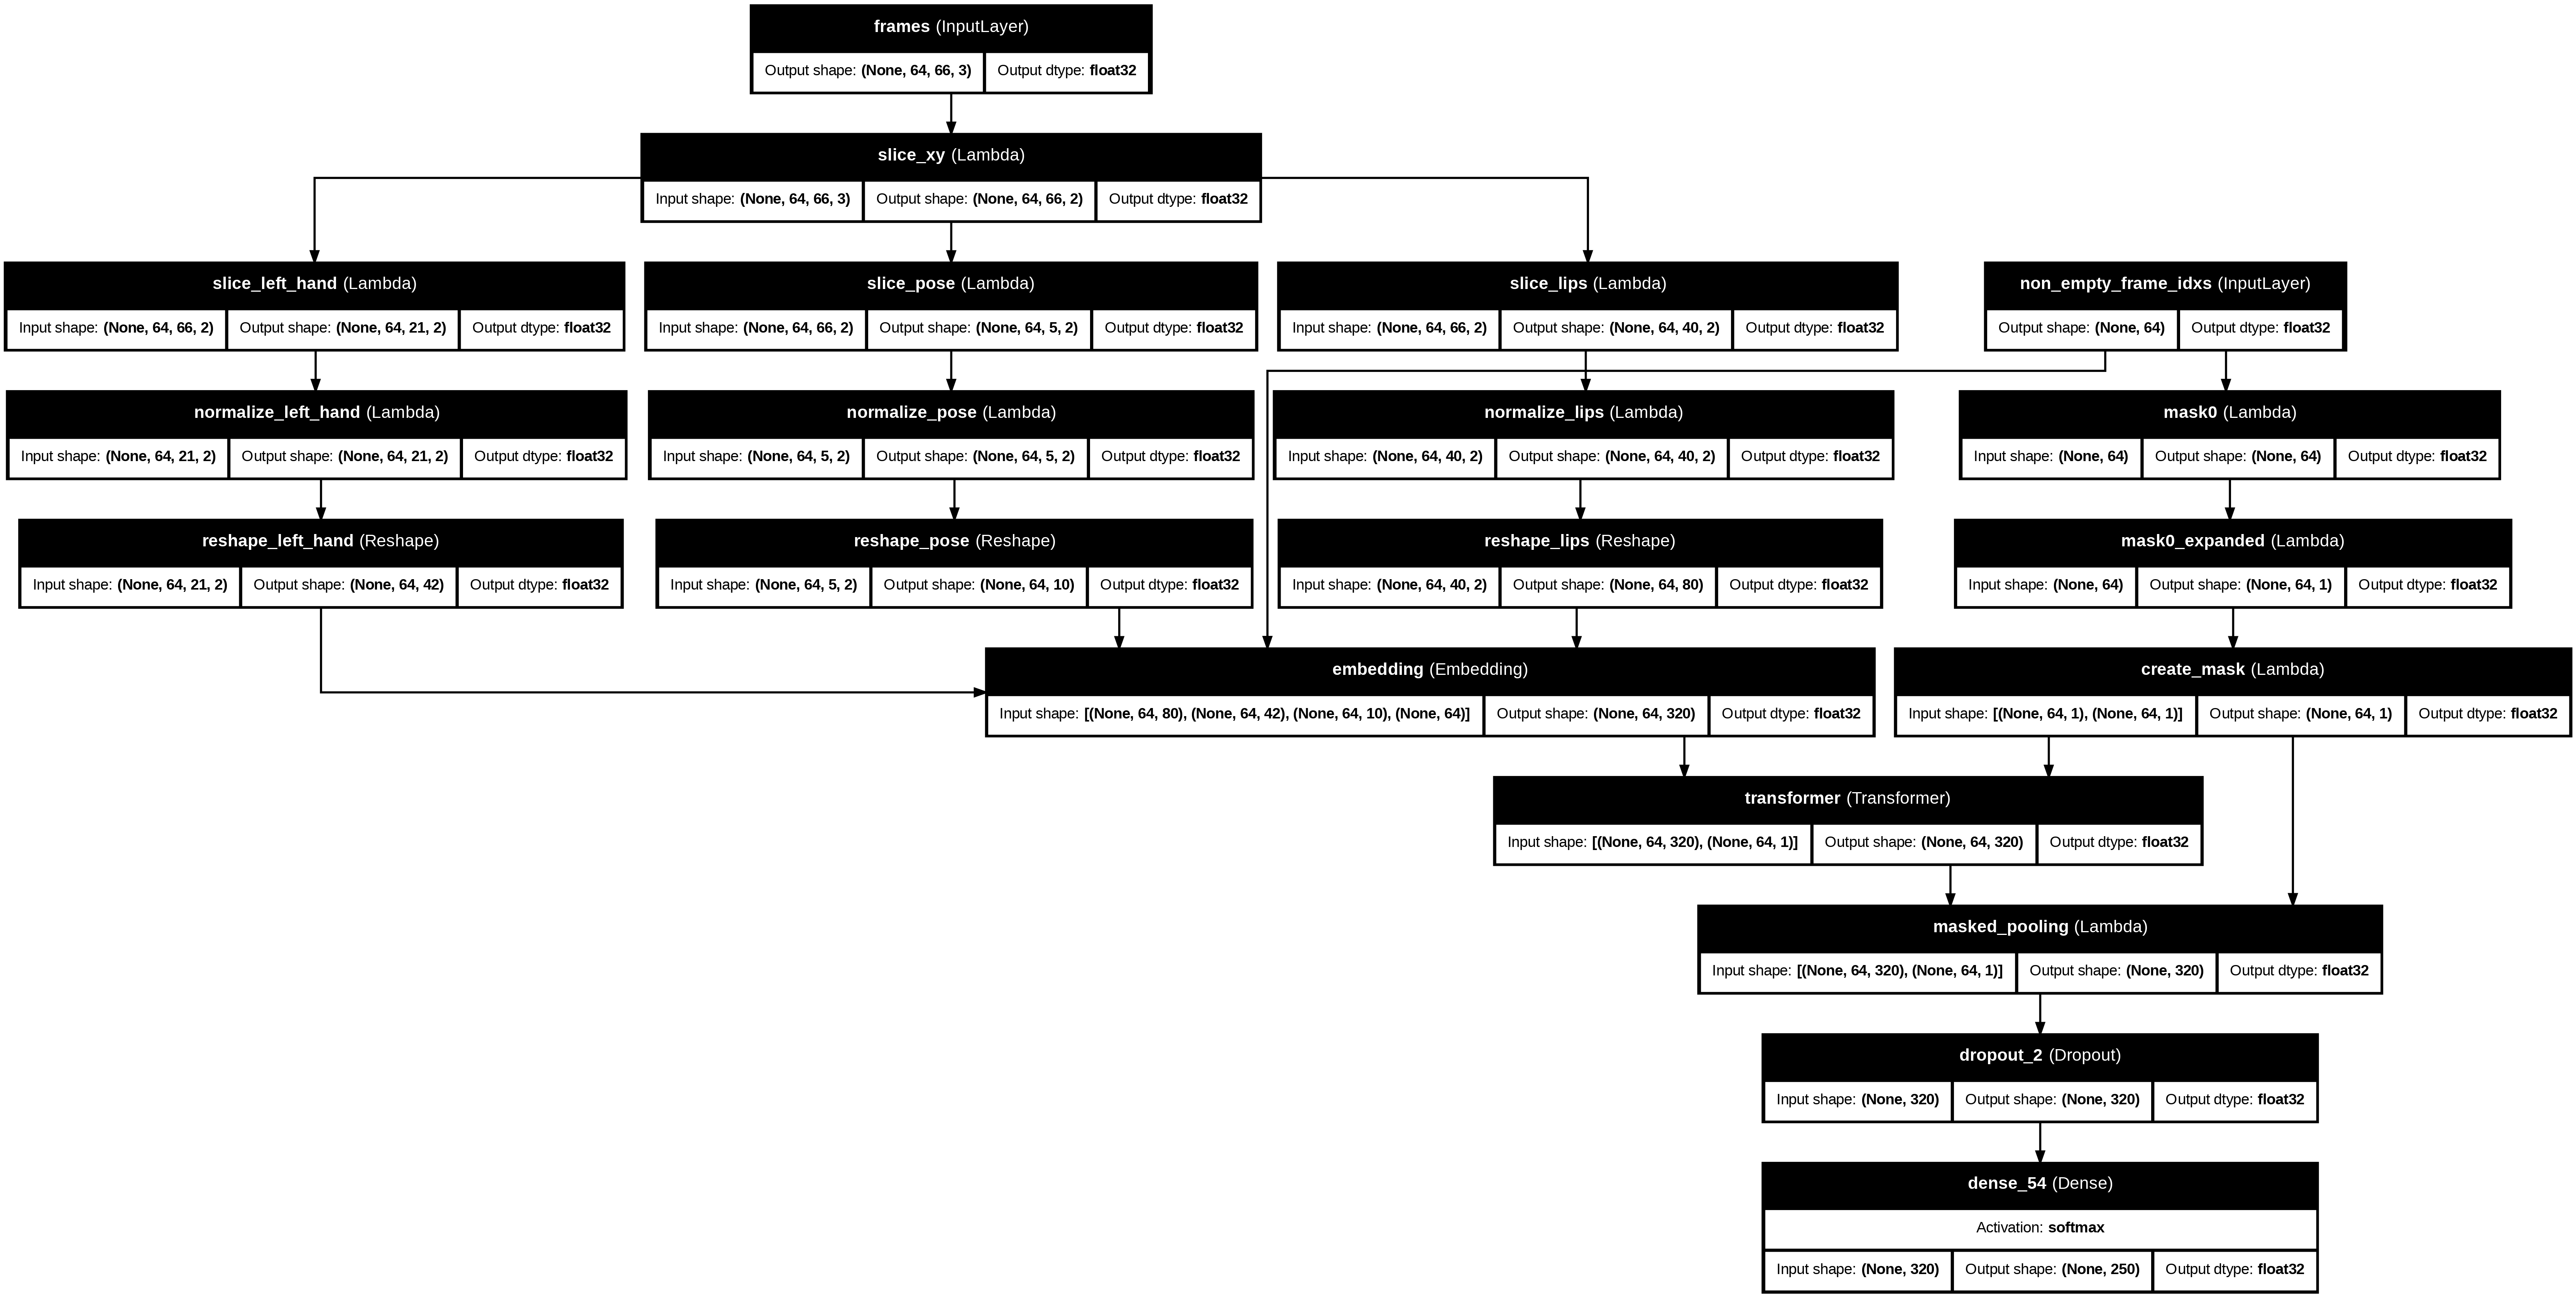

In [42]:
tf.keras.utils.plot_model(model, show_shapes=True, show_dtype=True, show_layer_names=True, expand_nested=True, show_layer_activations=True) 

# No NaN Predictions

In [43]:
if not PREPROCESS_DATA and TRAIN_MODEL:
    y_pred = model.predict_on_batch(X_batch).flatten()
    print(f'# NaN Values In Prediction: {np.isnan(y_pred).sum()}') 

I0000 00:00:1769548368.544192      70 service.cc:152] XLA service 0x78304c003800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769548368.544238      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769548368.895837      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


# NaN Values In Prediction: 0


I0000 00:00:1769548371.166819      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# Weight Initialization

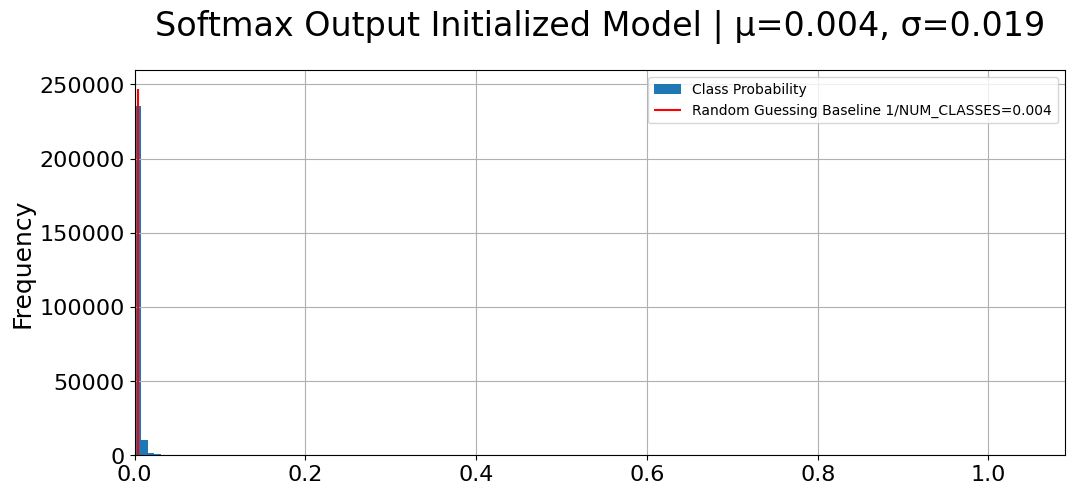

In [44]:
if not PREPROCESS_DATA and TRAIN_MODEL:
    plt.figure(figsize=(12,5))
    plt.title(f'Softmax Output Initialized Model | µ={y_pred.mean():.3f}, σ={y_pred.std():.3f}', pad=25)
    pd.Series(y_pred).plot(kind='hist', bins=128, label='Class Probability')
    plt.xlim(0, max(y_pred) * 1.1)
    plt.vlines([1 / NUM_CLASSES], 0, plt.ylim()[1], color='red', label=f'Random Guessing Baseline 1/NUM_CLASSES={1 / NUM_CLASSES:.3f}')
    plt.grid()
    plt.legend()
    plt.show() 

# Learning rate Scheduler

In [45]:
#def lrfn(current_step, num_warmup_steps, lr_max, num_cycles=0.50, num_training_steps=N_EPOCHS):
    
    #if current_step < num_warmup_steps:
        #if WARMUP_METHOD == 'log':
            #return lr_max * 0.10 ** (num_warmup_steps - current_step)
        #else:
            #return lr_max * 2 ** -(num_warmup_steps - current_step)
    #else:
        #progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))

        #return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress))) * lr_max 

In [46]:
def plot_lr_schedule(lr_schedule, epochs):
    fig = plt.figure(figsize=(20, 10))
    plt.plot([None] + lr_schedule + [None])
    # X Labels
    x = np.arange(1, epochs + 1)
    x_axis_labels = [i if epochs <= 40 or i % 5 == 0 or i == 1 else None for i in range(1, epochs + 1)]
    plt.xlim([1, epochs])
    plt.xticks(x, x_axis_labels) # set tick step to 1 and let x axis start at 1
    
    plt.ylim([0, max(lr_schedule) * 1.1])
    
    # Title
    schedule_info = f'start: {lr_schedule[0]:.1E}, max: {max(lr_schedule):.1E}, final: {lr_schedule[-1]:.1E}'
    plt.title(f'Step Learning Rate Schedule, {schedule_info}', size=18, pad=12)
    
    # Plot Learning Rates
    for x, val in enumerate(lr_schedule):
        if epochs <= 40 or x % 5 == 0 or x is epochs - 1:
            if x < len(lr_schedule) - 1:
                if lr_schedule[x - 1] < val:
                    ha = 'right'
                else:
                    ha = 'left'
            elif x == 0:
                ha = 'right'
            else:
                ha = 'left'
            plt.plot(x + 1, val, 'o', color='black');
            offset_y = (max(lr_schedule) - min(lr_schedule)) * 0.02
            plt.annotate(f'{val:.1E}', xy=(x + 1, val + offset_y), size=12, ha=ha)
    
    plt.xlabel('Epoch', size=16, labelpad=5)
    plt.ylabel('Learning Rate', size=16, labelpad=5)
    plt.grid()
    plt.show()

# Calculate total steps
STEPS_PER_EPOCH = N_SAMPLES // BATCH_SIZE
TOTAL_STEPS = N_EPOCHS * STEPS_PER_EPOCH

def generate_one_cycle_step_wise(lr_max, total_steps, warmup_prop=0.3):
    lr_schedule = []
    warmup_steps = int(total_steps * warmup_prop)
    cooldown_steps = total_steps - warmup_steps
    
    initial_lr = lr_max / 25.0
    final_lr = lr_max / 10000.0
    
    for step in range(total_steps):
        if step < warmup_steps:
            lr = initial_lr + (lr_max - initial_lr) * (step / warmup_steps)
        else:
            progress = (step - warmup_steps) / cooldown_steps
            lr = final_lr + (lr_max - final_lr) * (0.5 * (1 + math.cos(math.pi * progress)))
        lr_schedule.append(lr)
    return lr_schedule

# Generate high-resolution schedule
LR_SCHEDULE_STEPS = generate_one_cycle_step_wise(LR_MAX, TOTAL_STEPS, warmup_prop=0.3)

# Custom Callback to update every BATCH
class StepLearningRateScheduler(tf.keras.callbacks.Callback):
    def __init__(self, schedule):
        super(StepLearningRateScheduler, self).__init__()
        self.schedule = schedule

    def on_train_batch_begin(self, batch, logs=None):
        # Calculate global step
        global_step = self.model.optimizer.iterations.numpy()
        if global_step < len(self.schedule):
            lr = self.schedule[global_step]
            self.model.optimizer.learning_rate.assign(lr)

lr_callback = StepLearningRateScheduler(LR_SCHEDULE_STEPS) 

# Weight Decay Callback

In [47]:
# Custom callback to update weight decay with learning rate
class WeightDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, wd_ratio=WD_RATIO):
        self.step_counter = 0
        self.wd_ratio = wd_ratio
    
    def on_epoch_begin(self, epoch, logs=None):
        model.optimizer.weight_decay = model.optimizer.learning_rate * self.wd_ratio
        print(f'learning rate: {model.optimizer.learning_rate.numpy():.2e}, weight decay: {model.optimizer.weight_decay.numpy():.2e}') 

# Performance Benchmark

In [48]:
# Custom callback to update weight decay with learning rate
class WeightDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, wd_ratio=WD_RATIO):
        self.step_counter = 0
        self.wd_ratio = wd_ratio
    
    def on_epoch_begin(self, epoch, logs=None):
        model.optimizer.weight_decay = model.optimizer.learning_rate * self.wd_ratio
        print(f'learning rate: {model.optimizer.learning_rate.numpy():.2e}, weight decay: {model.optimizer.weight_decay.numpy():.2e}') 

# Training

In [49]:
if USE_VAL:
    # Verify val dataset covers all signs
    print(f'# Unique Signs in Validation Set: {pd.Series(y_val).nunique()}')
    # Value Counts
    display(pd.Series(y_val).value_counts().to_frame('Count').iloc[[1,2,3,-3,-2,-1]]) 

# Unique Signs in Validation Set: 250


,Count
38,67
235,66
172,66
106,43
170,35
249,32


In [50]:
# Sanity Check
if TRAIN_MODEL and USE_VAL:
    _ = model.evaluate(*validation_data, verbose=2) 

446/446 - 7s - 16ms/step - acc: 0.0032 - loss: 5.5336 - top_10_acc: 0.0361 - top_5_acc: 0.0175


In [51]:
# Ensure validation labels are one-hot for CCE\n
if TRAIN_MODEL and USE_VAL:
    try:
        # Assuming validation_data is tuple (X, y)\n
        if isinstance(validation_data, tuple) or isinstance(validation_data, list):
            val_inputs, val_labels = validation_data
            if len(val_labels.shape) == 1:
                print('Converting validation labels to One-Hot')
                val_labels_oh = tf.one_hot(val_labels, NUM_CLASSES)
                validation_data = (val_inputs, val_labels_oh)
    except Exception as e:
        print(f'Warning: Could not auto-convert validation labels: {e}')

In [52]:
# !pip install keras-tuner

if TRAIN_MODEL:
    tf.keras.backend.clear_session()

    import kerastuner as kt
    
    def model_builder(hp):
        # Tune params
        global UNITS, NUM_BLOCKS, LR_MAX
        UNITS = hp.Int('units', min_value=256, max_value=512, step=64)
        NUM_BLOCKS = hp.Int('num_blocks', min_value=1, max_value=3)
        LR_MAX = hp.Choice('lr_max', values=[1e-3, 5e-4, 1e-4])
        model = get_model()  
        return model
    
    if False:  # Set to True to tune (resource-heavy)
        tuner = kt.Hyperband(model_builder,
                             objective='val_acc',
                             max_epochs=20,
                             factor=3,
                             directory='my_dir',
                             project_name='sign_tuning')
        tuner.search(get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN),
                     steps_per_epoch=len(X_train) // (NUM_CLASSES * BATCH_ALL_SIGNS_N),
                     epochs=20,
                     validation_data=validation_data,
                     callbacks=[lr_callback, WeightDecayCallback()])
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        model = tuner.hypermodel.build(best_hps)
        print(f"Best units: {best_hps.get('units')}, blocks: {best_hps.get('num_blocks')}, lr: {best_hps.get('lr_max')}")

    # Normal training
    else:
        model = get_model()
    
    model.summary()

    # Add early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

    history = model.fit(
            x=get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN),
            steps_per_epoch=len(X_train) // (NUM_CLASSES * BATCH_ALL_SIGNS_N),
            epochs=N_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=validation_data,
            callbacks=[
                early_stopping,
                lr_callback,
                WeightDecayCallback(),
            ],
            verbose=VERBOSE,
        ) 

/tmp/ipykernel_24/1404461548.py:6: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 64, 66, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_xy (Lambda)   │ (None, 64, 66, 2) │          0 │ frames[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_lips (Lambda) │ (None, 64, 40, 2) │          0 │ slice_xy[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_left_hand     │ (None, 64, 21, 2) │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_pose (Lambda) │ (None, 64, 5, 2)  │          0 │ slice_xy[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ non_empty_frame_id… │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_lips      │ (None, 64, 40, 2) │          0 │ slice_lips[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_left_hand │ (None, 64, 21, 2) │          0 │ slice_left_hand[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_pose      │ (None, 64, 5, 2)  │          0 │ slice_pose[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask0 (Lambda)      │ (None, 64)        │          0 │ non_empty_frame_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_lips        │ (None, 64, 80)    │          0 │ normalize_lips[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_left_hand   │ (None, 64, 42)    │          0 │ normalize_left_h… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_pose        │ (None, 64, 10)    │          0 │ normalize_pose[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask0_expanded      │ (None, 64, 1)     │          0 │ mask0[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 320)   │    321,152 │ reshape_lips[0][… │
│ (Embedding)         │                   │            │ reshape_left_han… │
│                     │                   │            │ reshape_pose[0][… │
│                     │                   │            │ non_empty_frame_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ create_mask         │ (None, 64, 1)     │          0 │ mask0_expanded[0… │
│ (Lambda)            │                   │            │ mask0_expanded[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer         │ (None, 64, 320)   │  1,642,880 │ embedding[0][0],  │
│ (Transformer)       │                   │            │ create_mask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_pooling      │ (None, 320)       │          0 │ transformer[0][0

 Total params: 2,044,282 (7.80 MB)

 Trainable params: 2,044,282 (7.80 MB)

 Non-trainable params: 0 (0.00 B)

learning rate: 1.00e-03, weight decay: 5.00e-05
Epoch 1/100
80/80 - 103s - 1s/step - acc: 0.0062 - loss: 5.6893 - top_10_acc: 0.0529 - top_5_acc: 0.0280 - val_acc: 0.0233 - val_loss: 5.4445 - val_top_10_acc: 0.1390 - val_top_5_acc: 0.0844
learning rate: 7.24e-05, weight decay: 3.62e-06
Epoch 2/100
80/80 - 62s - 770ms/step - acc: 0.0138 - loss: 5.4945 - top_10_acc: 0.1035 - top_5_acc: 0.0587 - val_acc: 0.0449 - val_loss: 5.2778 - val_top_10_acc: 0.2448 - val_top_5_acc: 0.1552
learning rate: 1.05e-04, weight decay: 5.26e-06
Epoch 3/100
80/80 - 62s - 773ms/step - acc: 0.0260 - loss: 5.3649 - top_10_acc: 0.1679 - top_5_acc: 0.0994 - val_acc: 0.0697 - val_loss: 5.0531 - val_top_10_acc: 0.3551 - val_top_5_acc: 0.2363
learning rate: 1.38e-04, weight decay: 6.90e-06
Epoch 4/100
80/80 - 62s - 774ms/step - acc: 0.0393 - loss: 5.2412 - top_10_acc: 0.2343 - top_5_acc: 0.1440 - val_acc: 0.1090 - val_loss: 4.8480 - val_top_10_acc: 0.4951 - val_top_5_acc: 0.3460
learning rate: 1.71e-04, weight decay:

In [53]:
# Save Model Weights
model.save_weights('model.weights.h5') 

In [54]:
if USE_VAL:
    # val dataset predictions
    y_val_pred = model.predict({ 'frames': X_val, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL }, verbose=2).argmax(axis=1)
    # Label
    labels = [ORD2SIGN.get(i).replace(' ', '_') for i in range(NUM_CLASSES)] 

446/446 - 7s - 16ms/step


# Landmark Attention Weights

In [55]:
# Landmark Weights
#for w in model.get_layer('embedding').weights:
    #if 'landmark_weights' in w.name:
        #weights = scipy.special.softmax(w)

#landmarks = ['lips_embedding', 'left_hand_embedding', 'pose_embedding']

#for w, lm in zip(weights, landmarks):
    #print(f'{lm} weight: {(w*100):.1f}%')  

In [56]:
embedding_layer = None
for layer in model.layers:
    if 'embedding' in layer.name:
        embedding_layer = layer
        break

if embedding_layer is None:
    raise RuntimeError("Embedding layer not found in the model.")

landmark_weights_var = getattr(embedding_layer, 'landmark_weights', None)

if landmark_weights_var is None:
    raise RuntimeError("'landmark_weights' attribute not found in the embedding layer.")

# Convert to numpy and apply softmax for readable weights
import scipy

weights = scipy.special.softmax(landmark_weights_var.numpy())

# Print weights
landmarks = ['lips_embedding', 'left_hand_embedding', 'pose_embedding']

for w, lm in zip(weights, landmarks):
    print(f'{lm} weight: {(w * 100):.1f}%') 

lips_embedding weight: 33.3%
left_hand_embedding weight: 33.3%
pose_embedding weight: 33.3%


# Classification Report

In [57]:
def print_classification_report():
    # Classification report for all signs
    classification_report = sklearn.metrics.classification_report(
            y_val,
            y_val_pred,
            target_names=labels,
            output_dict=True,
        )
    # Round Data for better readability
    classification_report = pd.DataFrame(classification_report).T
    classification_report = classification_report.round(2)
    classification_report = classification_report.astype({
            'support': np.uint16,
        })
    # Add signs
    classification_report['sign'] = [e if e in SIGN2ORD else -1 for e in classification_report.index]
    classification_report['sign_ord'] = classification_report['sign'].apply(SIGN2ORD.get).fillna(-1).astype(np.int16)
    # Sort on F1-score
    classification_report = pd.concat((
        classification_report.head(NUM_CLASSES).sort_values('f1-score', ascending=False),
        classification_report.tail(3),
    ))

    pd.options.display.max_rows = 999
    display(classification_report)

In [58]:
if USE_VAL:
    print_classification_report() 

,precision,recall,f1-score,support,sign,sign_ord
gum,0.98,0.98,0.98,59,gum,103
brown,0.97,0.98,0.97,58,brown,31
frog,0.96,0.98,0.97,54,frog,90
horse,0.95,0.98,0.97,60,horse,119
doll,0.97,0.95,0.96,61,doll,59
airplane,0.95,0.96,0.96,57,airplane,2
owl,1.00,0.91,0.95,57,owl,165
shirt,0.93,0.96,0.95,54,shirt,195
police,0.98,0.92,0.95,60,police,174
cow,0.91,0.98,0.94,60,cow,50


# Training History

In [59]:
def plot_history_metric(metric, f_best=np.argmax, ylim=None, yscale=None, yticks=None):
    plt.figure(figsize=(20, 10))
    
    values = history.history[metric]
    N_EPOCHS = len(values)
    val = 'val' in ''.join(history.history.keys())
    # Epoch ticks
    if N_EPOCHS <= 20:
        x = np.arange(1, N_EPOCHS + 1)
    else:
        x = [1, 5] + [10 + 5 * idx for idx in range((N_EPOCHS - 10) // 5 + 1)]

    x_ticks = np.arange(1, N_EPOCHS+1)

    # Validation
    if val:
        val_values = history.history[f'val_{metric}']
        val_argmin = f_best(val_values)
        plt.plot(x_ticks, val_values, label=f'val')

    # summarize history for accuracy
    plt.plot(x_ticks, values, label=f'train')
    argmin = f_best(values)
    plt.scatter(argmin + 1, values[argmin], color='red', s=75, marker='o', label=f'train_best')
    if val:
        plt.scatter(val_argmin + 1, val_values[val_argmin], color='purple', s=75, marker='o', label=f'val_best')

    plt.title(f'Model {metric}', fontsize=24, pad=10)
    plt.ylabel(metric, fontsize=20, labelpad=10)

    if ylim:
        plt.ylim(ylim)

    if yscale is not None:
        plt.yscale(yscale)
        
    if yticks is not None:
        plt.yticks(yticks, fontsize=16)

    plt.xlabel('epoch', fontsize=20, labelpad=10)        
    plt.tick_params(axis='x', labelsize=8)
    plt.xticks(x, fontsize=16) # set tick step to 1 and let x axis start at 1
    plt.yticks(fontsize=16)
    
    plt.legend(prop={'size': 10})
    plt.grid()
    plt.show()

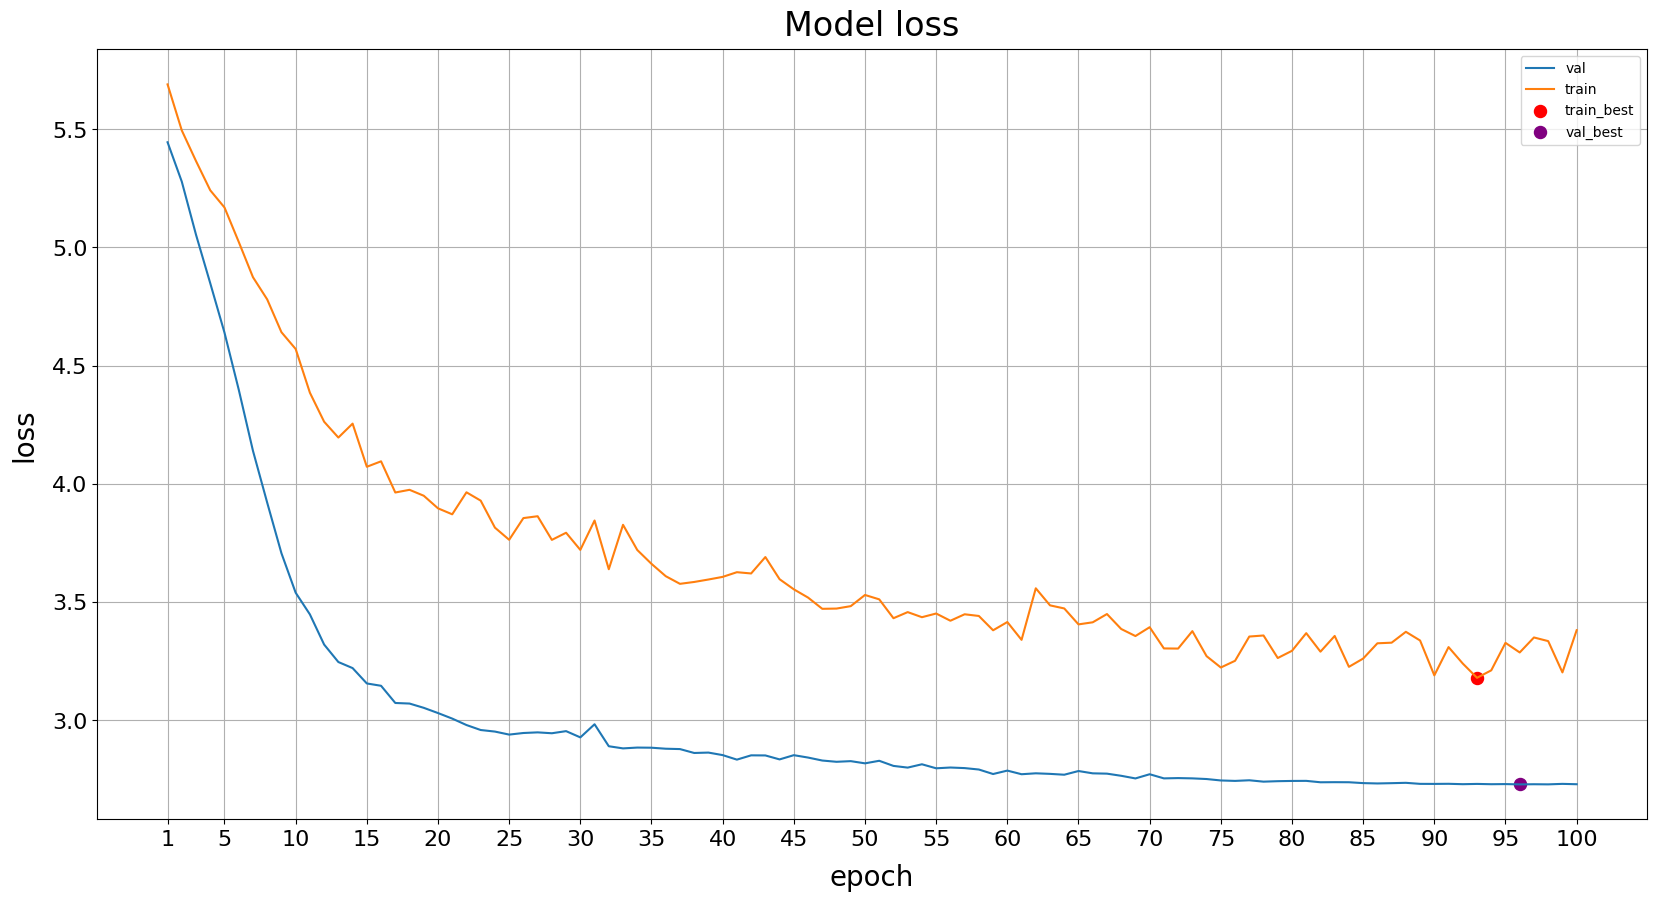

In [60]:
if TRAIN_MODEL:
    plot_history_metric('loss', f_best=np.argmin) 

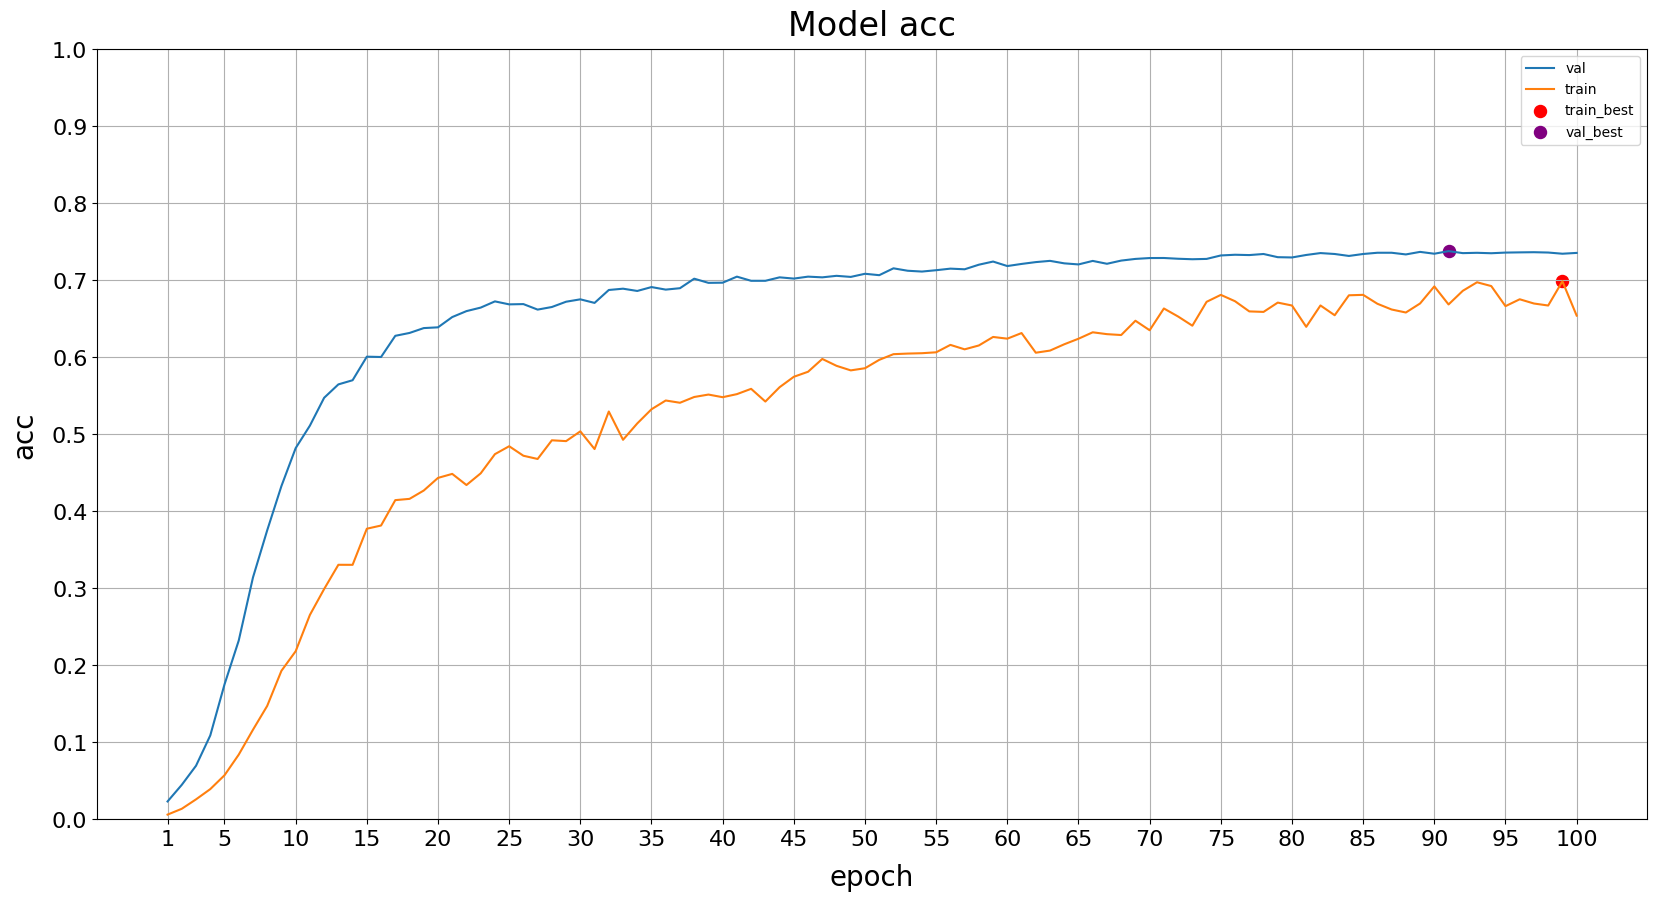

In [61]:
if TRAIN_MODEL:
    plot_history_metric('acc', ylim=[0,1], yticks=np.arange(0.0, 1.1, 0.1)) 

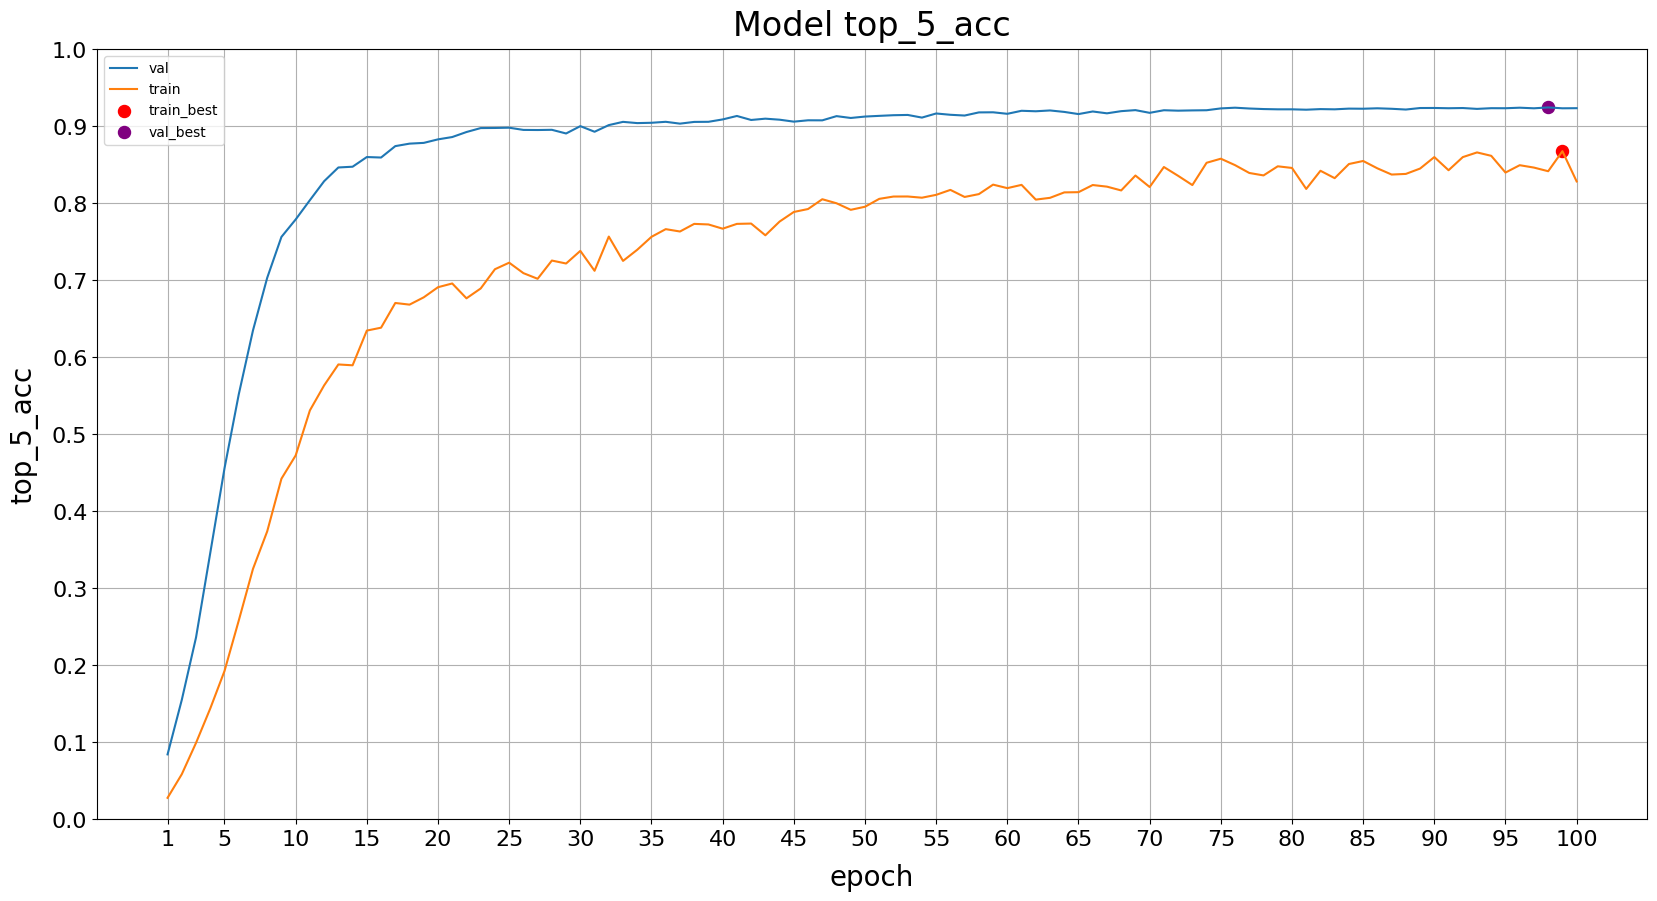

In [62]:
if TRAIN_MODEL:
    plot_history_metric('top_5_acc', ylim=[0,1], yticks=np.arange(0.0, 1.1, 0.1))

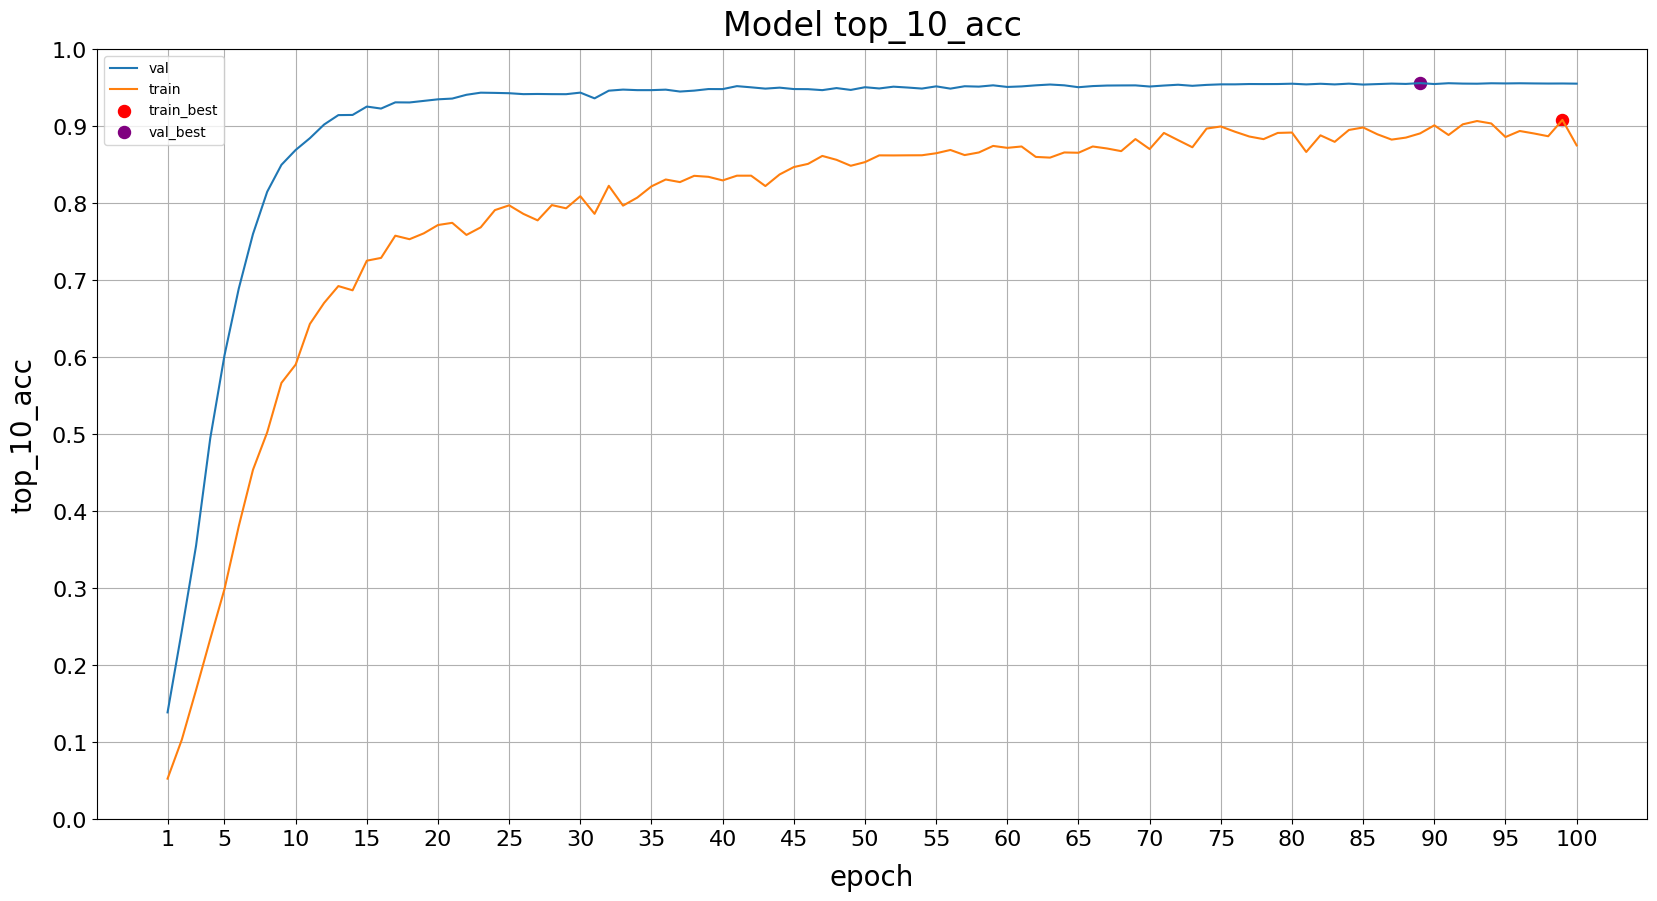

In [63]:
if TRAIN_MODEL:
    plot_history_metric('top_10_acc', ylim=[0,1], yticks=np.arange(0.0, 1.1, 0.1))

# TFLite Model Conversion

In [64]:
class TFLiteModel(tf.Module):
    def __init__(self, model):
        super(TFLiteModel, self).__init__()
        self.model = model
        
        # Initialize Normalization Correction (Copied from PreprocessLayer)
        normalisation_correction = tf.constant([
                    # Add 0.50 to left hand (original right hand) and substract 0.50 of right hand (original left hand)
                    [0] * len(LIPS_IDXS) + [0.50] * len(LEFT_HAND_IDXS) + [0.50] * len(POSE_IDXS),
                    # Y coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                    # Z coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                ],
                dtype=tf.float32,
            )
        self.normalisation_correction = tf.transpose(normalisation_correction, [1,0])

    def pad_edge(self, t, repeats, side):
        if side == 'LEFT':
            return tf.concat((tf.repeat(t[:1], repeats=repeats, axis=0), t), axis=0)
        elif side == 'RIGHT':
            return tf.concat((t, tf.repeat(t[-1:], repeats=repeats, axis=0)), axis=0)

    @tf.function(input_signature=[tf.TensorSpec(shape=[None, 543, 3], dtype=tf.float32, name='inputs')])
    def __call__(self, data0):
        # Number of Frames in Video
        N_FRAMES0 = tf.shape(data0)[0]
        
        # Find dominant hand by comparing summed absolute coordinates
        left_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1))
        right_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1))
        left_dominant = left_hand_sum >= right_hand_sum
        
        # Count non-NaN Hand values in each frame for the dominant hand
        if left_dominant:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        else:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        
        # Find frames indices with coordinates of the dominant hand
        non_empty_frames_idxs = tf.where(frames_hands_non_nan_sum > 0)
        non_empty_frames_idxs = tf.squeeze(non_empty_frames_idxs, axis=1)
        # Filter frames
        data = tf.gather(data0, non_empty_frames_idxs, axis=0)
        
        # Cast Indices in float32 to be compatible with Tensorflow Lite
        non_empty_frames_idxs = tf.cast(non_empty_frames_idxs, tf.float32)
        # Normalize to start with 0
        non_empty_frames_idxs -= tf.reduce_min(non_empty_frames_idxs)
        
        # Number of Frames in Filtered Video
        N_FRAMES = tf.shape(data)[0]
        
        # Gather Relevant Landmark Columns
        if left_dominant:
            data = tf.gather(data, LANDMARK_IDXS_LEFT_DOMINANT0, axis=1)
        else:
            data = tf.gather(data, LANDMARK_IDXS_RIGHT_DOMINANT0, axis=1)
            data = (
                    self.normalisation_correction + (
                        (data - self.normalisation_correction) * tf.where(self.normalisation_correction != 0, -1.0, 1.0))
                )
        
        # Video fits in INPUT_SIZE
        if N_FRAMES < INPUT_SIZE:
            # Pad With -1 to indicate padding
            non_empty_frames_idxs = tf.pad(non_empty_frames_idxs, [[0, INPUT_SIZE-N_FRAMES]], constant_values=-1)
            # Pad Data With Zeros
            data = tf.pad(data, [[0, INPUT_SIZE-N_FRAMES], [0,0], [0,0]], constant_values=0)
            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
        # Video needs to be downsampled to INPUT_SIZE
        else:
            # Repeat
            if N_FRAMES < INPUT_SIZE**2:
                repeats = tf.math.floordiv(INPUT_SIZE * INPUT_SIZE, N_FRAMES0)
                data = tf.repeat(data, repeats=repeats, axis=0)
                non_empty_frames_idxs = tf.repeat(non_empty_frames_idxs, repeats=repeats, axis=0)

            # Pad To Multiple Of Input Size
            pool_size = tf.math.floordiv(len(data), INPUT_SIZE)
            if tf.math.mod(len(data), INPUT_SIZE) > 0:
                pool_size += 1

            if pool_size == 1:
                pad_size = (pool_size * INPUT_SIZE) - len(data)
            else:
                pad_size = (pool_size * INPUT_SIZE) % len(data)

            # Pad Start/End with Start/End value
            pad_left = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            pad_right = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            if tf.math.mod(pad_size, 2) > 0:
                pad_right += 1

            # Pad By Concatenating Left/Right Edge Values
            data = self.pad_edge(data, pad_left, 'LEFT')
            data = self.pad_edge(data, pad_right, 'RIGHT')

            # Pad Non Empty Frame Indices
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_left, 'LEFT')
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_right, 'RIGHT')

            # Reshape to Mean Pool
            data = tf.reshape(data, [INPUT_SIZE, -1, N_COLS, N_DIMS])
            non_empty_frames_idxs = tf.reshape(non_empty_frames_idxs, [INPUT_SIZE, -1])

            # Mean Pool
            data = tf.math.divide_no_nan(tf.reduce_sum(tf.where(tf.math.is_nan(data), 0.0, data), axis=1), tf.reduce_sum(tf.cast(tf.math.is_finite(data), tf.float32), axis=1))
            non_empty_frames_idxs = tf.math.divide_no_nan(tf.reduce_sum(tf.where(tf.math.is_nan(non_empty_frames_idxs), 0.0, non_empty_frames_idxs), axis=1), tf.reduce_sum(tf.cast(tf.math.is_finite(non_empty_frames_idxs), tf.float32), axis=1))

            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
            
        # Inference
        x = data
        
        outputs = self.model({'frames':tf.expand_dims(x, axis=0), 'non_empty_frame_idxs': tf.expand_dims(non_empty_frames_idxs, axis=0)})[0]

        # Return Dictionary
        return {'outputs': outputs}

tflite_keras_model = TFLiteModel(model)

In [65]:
import json
# Get concrete function
concrete_func = tflite_keras_model.__call__.get_concrete_function()

# Convert from concrete function
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func], tflite_keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Save TFLite Model
with open('inference.tflite', 'wb') as f:
    f.write(tflite_model)
    
# Zip for Submission
import zipfile

inference_args = {
    "selected_columns": [i for i in range(543)],
    "columns": ["x", "y", "z"]
}

with open('inference_args.json', 'w') as f:
    json.dump(inference_args, f)

with zipfile.ZipFile('submission.zip', 'w') as z:
    z.write('inference.tflite')
    z.write('inference_args.json')
    
print('Submission created: submission.zip')

I0000 00:00:1769554947.668680      24 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1769554947.668841      24 single_machine.cc:374] Starting new session
I0000 00:00:1769554947.669805      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
W0000 00:00:1769554948.594167      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1769554948.594202      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Submission created: submission.zip


In [66]:
# Configuration
TEST_DATA_DIR_EVAL = '/kaggle/input/461054610546105/test_landmark_files'
LABELS_PATH = '/kaggle/input/461054610546105/labels.parqet' 
MAP_PATH = '/kaggle/input/461054610546105/sign_to_prediction_index_map.json'

# Inspect the Data
labels_df = pd.read_parquet(LABELS_PATH)
print(f"Columns found: {labels_df.columns.tolist()}")
print("First 3 rows:")
display(labels_df.head(3))

Columns found: ['path', 'sign', 'Usage']
First 3 rows:


,path,sign,Usage
0,test_landmark_files/11672/1000061708.parquet,go,Private
1,test_landmark_files/14938/1000072466.parquet,read,Public
2,test_landmark_files/14938/1000109638.parquet,sleep,Public


In [67]:
import os
import json
from tqdm.notebook import tqdm

TEST_DATA_DIR_EVAL = '/kaggle/input/461054610546105/test_landmark_files'
LABELS_PATH = '/kaggle/input/461054610546105/labels.parqet'
MAP_PATH = '/kaggle/input/461054610546105/sign_to_prediction_index_map.json'
ROWS_PER_FRAME = 543

def load_relevant_data_subset(pq_path):
    data_columns = ['x', 'y', 'z']
    data = pd.read_parquet(pq_path, columns=data_columns)
    n_frames = int(len(data) / ROWS_PER_FRAME)
    data = data.values.reshape(n_frames, ROWS_PER_FRAME, 3)
    return data.astype(np.float32)

def evaluate_on_test_dir(test_dir, labels_path, map_path):
    if not os.path.exists(labels_path):
        print(f"Labels file not found at {labels_path}")
        return
        
    try:
        labels_df = pd.read_parquet(labels_path)
    except Exception as e:
        print(f"Error reading parquet labels: {e}")
        return

    if os.path.exists(map_path):
        with open(map_path, 'r') as f:
            sign_map = json.load(f)
    else:
        print("Sign map not found.")
        return
    
    # Storage
    X_test_frames = []
    X_test_idxs = []
    y_test = []
    processed_count = 0
    
    # Preprocess
    preprocess_layer = PreprocessLayer()
    
    print(f"Found {len(labels_df)} samples. Starting evaluation...")
    
    for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
        clean_rel_path = row['path'].replace('test_landmark_files/', '')
        
        # Construct full path
        file_path = os.path.join(test_dir, clean_rel_path)
        
        if not os.path.exists(file_path):
            file_path = os.path.join(test_dir, os.path.basename(row['path']))

        if os.path.exists(file_path):
            try:
                # Load Raw Data
                data = load_relevant_data_subset(file_path)
                
                # Preprocess (Convert to tensor for the layer)
                data_tf = tf.convert_to_tensor(data)
                frames, idxs = preprocess_layer(data_tf)
                
                # Store Features
                X_test_frames.append(frames.numpy())
                X_test_idxs.append(idxs.numpy())
                
                # Store Label
                sign = row['sign']
                if sign in sign_map:
                    y_test.append(sign_map[sign])
                
                processed_count += 1
                
            except Exception as e:
                # print(f"Error processing {file_path}: {e}")
                pass
    
    if processed_count == 0:
        print("CRITICAL: No samples were processed. Please check path structure again.")
        return

    # Convert to Arrays
    X_frames = np.array(X_test_frames)
    X_idxs = np.array(X_test_idxs)
    y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)
    
    print(f"Successfully processed {processed_count} samples.")
    
    # Evaluate Model
    results = model.evaluate({'frames': X_frames, 'non_empty_frame_idxs': X_idxs}, y_test_oh, verbose=1)
    
    print("-" * 30)
    print(f"Test Loss: {results[0]:.4f}")
    if len(results) > 1:
        print(f"Test Accuracy: {results[1]:.4f}")
    if len(results) > 2:
        print(f"Top-5 Accuracy: {results[2]:.4f}")

# Execute
evaluate_on_test_dir(TEST_DATA_DIR_EVAL, LABELS_PATH, MAP_PATH)

Found 39443 samples. Starting evaluation...


  0%|          | 0/39443 [00:00<?, ?it/s]

Successfully processed 39443 samples.
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - acc: 0.7588 - loss: 2.7131 - top_10_acc: 0.9402 - top_5_acc: 0.9136
------------------------------
Test Loss: 2.7102
Test Accuracy: 0.7603
Top-5 Accuracy: 0.9152


In [68]:
def load_and_evaluate(test_dir, labels_path, map_path):
    if not os.path.exists(labels_path):
        print(f"Labels file not found at {labels_path}")
        return None, None, None

    try:
        labels_df = pd.read_parquet(labels_path)
    except Exception as e:
        print(f"Error reading parquet labels: {e}")
        return None, None, None

    if os.path.exists(map_path):
        with open(map_path, 'r') as f:
            sign_map = json.load(f)
    else:
        print("Sign map not found.")
        return None, None, None
    
    X_test_frames = []
    X_test_idxs = []
    y_test = []
    processed_count = 0
    preprocess_layer = PreprocessLayer()
    
    print(f"Found {len(labels_df)} samples. Loading data...")
    
    for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
        clean_rel_path = row['path'].replace('test_landmark_files/', '')
        file_path = os.path.join(test_dir, clean_rel_path)
        
        if not os.path.exists(file_path):
            file_path = os.path.join(test_dir, os.path.basename(row['path']))

        if os.path.exists(file_path):
            try:
                data = load_relevant_data_subset(file_path)
                data_tf = tf.convert_to_tensor(data)
                frames, idxs = preprocess_layer(data_tf)
                
                X_test_frames.append(frames.numpy())
                X_test_idxs.append(idxs.numpy())
                
                sign = row['sign']
                if sign in sign_map:
                    y_test.append(sign_map[sign])
                
                processed_count += 1
            except Exception:
                pass

    if processed_count == 0:
        return None, None, None

    # Convert to Arrays
    X_frames = np.array(X_test_frames)
    X_idxs = np.array(X_test_idxs)
    y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)
    
    print(f"Data Loaded. Shape: {X_frames.shape}")
    
    # Evaluate immediately
    results = model.evaluate({'frames': X_frames, 'non_empty_frame_idxs': X_idxs}, y_test_oh, verbose=1)
    print(f"Test Accuracy: {results[1]:.4f}")
    
    # RETURN the data
    return X_frames, X_idxs, y_test_oh

# Execute and capture variables
X_frames, X_idxs, y_test_oh = load_and_evaluate(TEST_DATA_DIR_EVAL, LABELS_PATH, MAP_PATH)

Found 39443 samples. Loading data...


  0%|          | 0/39443 [00:00<?, ?it/s]

Data Loaded. Shape: (39443, 64, 66, 3)
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.7574 - loss: 2.7133 - top_10_acc: 0.9392 - top_5_acc: 0.9128
Test Accuracy: 0.7595


In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

if X_frames is not None:
    # Get Predictions
    print("Generating predictions...")
    y_pred_probs = model.predict({'frames': X_frames, 'non_empty_frame_idxs': X_idxs}, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_oh, axis=1)

    # Compute Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Filter for "Most Confused" Pairs
    np.fill_diagonal(cm, 0) 
    indices = np.where(cm > 10) # Adjust threshold (e.g., >5 errors)

    # Map Indices to Sign Names
    if os.path.exists(MAP_PATH):
        with open(MAP_PATH, 'r') as f:
            sign_map = json.load(f)
        idx2sign = {v: k for k, v in sign_map.items()}
    else:
        idx2sign = {i: str(i) for i in range(NUM_CLASSES)}

    confused_pairs = []
    for i, j in zip(indices[0], indices[1]):
        confused_pairs.append({
            'True Sign': idx2sign[i],
            'Predicted Sign': idx2sign[j],
            'Count': cm[i, j]
        })

    df_confusion = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False)
    
    print(f"Top 10 Most Confused Signs:")
    display(df_confusion.head(10))
    
else:
    print("Data load failed.")

Generating predictions...
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step
Top 10 Most Confused Signs:


,True Sign,Predicted Sign,Count
4,awake,wake,94
92,wake,awake,58
38,glasswindow,tooth,57
37,finger,wait,50
60,mouth,lips,44
14,chin,lips,38
68,pencil,pen,38
76,scissors,cut,37
26,dryer,dry,37
46,hear,ear,33
